# Singapore Tourism Board — Data Pilot Submission

## A three-part answer to the assignment questions

This notebook uses STAN datasets (visitor arrivals, receipts, hotel and Visitor-Profile survey data in `data/`) to answer the three questions, and combines them with external public datasets (ECB/Frankfurter exchange rates, World Bank GDP per capita, SingStat CPI, Open-Meteo temperature and holiday calendars) where they add net-new insight.

* **Question 1 — Performance snapshot.** How is Singapore tourism performing
  recently? Strength *and* concern, told from volume, value, market mix and
  seasonality (Part Q1).
* **Question 2 — Data meshing.** Mesh STAN data with external public data to
  understand what visitors **really do** and how that knowledge could drive
  value / industry partnerships (Part Q2). The "*uniquely Singaporean*" venue
  tiering and its tests live here, as data-meshing evidence — not in setup.
* **Question 3 — Insights generation.** Translate the findings into insights
  about key visitor segments (top markets, companions, places visited, spend),
  infer preferences for at least two segments, and close with **one specific,
  data-backed hypothesis** for a future pilot (Part Q3).



## Contents

* Setup — Data & feature groundwork	- Import and clean the 6 STB workbooks into tidy tables. Build 2019 baselines.
* Q1 — Performance snapshot	- Answer: Volume, value (nominal & CPI-real), receipt mix, seasonality, market/age profiles. Identify strengths vs concerns.
* Q2 — Data meshing	- Mesh external data: uniqueness venue-tiering + cross‑national tests, FX & purchasing-power residuals, receipts-by-residence, temperature/holiday seasonality correspondence.
* Q3 — Insights generation - Build segment profiles (purpose, companions). Derive ≥2 segment inferences. Propose a future‑pilot hypothesis.
* Conclusion & limitations
* Assumptions & Decisions 
* Annex — Bibliography

# Setup — Data & feature groundwork

Reads all six STB source workbooks from `data/`, cleans them into tidy long-form tables, and builds the baseline features every question needs (2019 = 100 etc).

External-data pipeline (a live-fetch + cache layer) is also defined here so that later questions can pull ECB/Frankfurter FX, World Bank GDP per capita, SingStat CPI, and Open-Meteo temperature / holiday calendars.


In [31]:
import os
import re
import math
import json
import time
import urllib.request
import urllib.parse
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = "data"                               # raw STB workbooks (single originals)
CLEAN_DIR = "cleaned_data"                      # single canonical output dir for cleaned artefacts
os.makedirs(CLEAN_DIR, exist_ok=True)

def _restore_period(df, col="date"):
    """Reload cleaned CSV date strings ('2019-01', '2019Q1') back to Period objects
    so .dt.year / .dt.quarter / .dt.month and str(period) behave as in the freshly
    cleaned in-memory frames. Builds each Period per-element (NaN-tolerant) so the
    frequency is always explicit and never left to whole-series inference."""
    df = df.copy()
    out = []
    for x in df[col]:
        s = str(x)
        if s in ("", "nan", "NaT", "<NA>") or pd.isna(x):
            out.append(pd.NaT)
        else:
            out.append(pd.Period(s))
    df[col] = out
    return df

def cleaned_or_clean(csv_name, raw_path, build_fn, build_kwargs=None):
    """Load cleaned_data/<csv_name> if it already exists (no re-clean); else build it
    from the raw STB workbook and save it to cleaned_data/. Re-deriving (re)writes the
    canonical artefact so this notebook remains the single producer of cleaned_data/."""
    p = os.path.join(CLEAN_DIR, csv_name)
    if os.path.exists(p):
        df = _restore_period(pd.read_csv(p))
        print(f"[cleaned] loaded existing {p} (rows={len(df):,})")
        return df
    df = build_fn(raw_path, **(build_kwargs or {}))
    os.makedirs(CLEAN_DIR, exist_ok=True)
    df.to_csv(p, index=False)
    print(f"[cleaned] cleaned + wrote {p} (rows={len(df):,})")
    return df

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})

# ---- shared parsing helpers ----

def find_header_row(raw, marker="Data Series"):
    col0 = raw.iloc[:, 0].fillna("").astype(str).str.strip()
    hits = col0[col0 == marker]
    if hits.empty:
        raise ValueError(f"marker {marker!r} not found")
    return int(hits.index[0])

def _norm_token(tok):
    tok = str(tok).strip()
    return tok[:-2] if tok.endswith(".0") else tok

def parse_period_cols(labels, freq=None):
    labels = [_norm_token(l) for l in labels if str(l).strip() not in ("", "nan")]
    parts0 = labels[0].split()
    if freq is None:
        freq = ("M" if (len(parts0) > 1 and parts0[-1].isalpha())
                else ("Q" if (len(parts0) > 1 and "Q" in parts0[-1]) else "Y"))
    out = []
    for lab in labels:
        p = lab.split()
        if freq == "M":
            out.append(pd.Period(f"{p[0]}-{p[1]}", freq="M"))
        elif freq == "Q":
            qn = "".join(ch for ch in p[1] if ch.isdigit())
            out.append(pd.Period(f"{p[0]}Q{qn}", freq="Q"))
        else:
            out.append(pd.Period(p[0], freq="Y"))
    return pd.PeriodIndex(out)

def clean_label(label):
    s = str(label).replace("\n", " ").strip()
    return re.sub(r"\d+$", "", s).strip()

def classify_level(raw_label):
    text = str(raw_label)
    indent = len(text) - len(text.lstrip(" "))
    if "total" in text.strip().lower():
        return "total"
    return "group" if indent < 4 else "item"

def _coerce(cell_text):
    s = str(cell_text).replace(",", "").strip()
    return pd.to_numeric(s if s not in ("-", "") else np.nan, errors="coerce")

def load_wide_table(path, sheet, total_labels=()):
    '''Melt one wide STB sheet into [series, level, date, value].
    Positional .values access for pandas-3.0 safety.'''
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    hdr = find_header_row(raw)
    dates = parse_period_cols(raw.iloc[hdr].tolist()[1:])
    body = raw.iloc[hdr + 1:, :].reset_index(drop=True)
    stop = len(body)
    col0 = [str(x) if x == x else "" for x in body.values[:, 0]]
    for i, v in enumerate(col0):
        v = v.strip()
        if v.startswith(("Definitions", "Source:", "Notes:", "Generated by",
                         "Data accurate")) or v in ("", "nan"):
            stop = i
            break
    body = body.iloc[:stop]
    values = body.values
    rows = []
    for r_i in range(values.shape[0]):
        label_raw = values[r_i, 0]
        if label_raw is None or str(label_raw).strip() in ("", "nan"):
            continue
        series = clean_label(label_raw)
        level = ("total" if series in tuple(total_labels)
                 else classify_level(label_raw))
        for d_i, dt in enumerate(dates):
            val = _coerce(values[r_i, d_i + 1])
            if pd.notna(val):
                rows.append((series, level, dt, val))
    return (pd.DataFrame(rows, columns=["series", "level", "date", "value"])
            .sort_values(["series", "level", "date"]).reset_index(drop=True))

def load_profile_sheet(path, sheet):
    '''Visitor Profile sheet -> [year, region, residence, metric, unit, value].'''
    pf = pd.read_excel(path, sheet_name=sheet, header=None)
    hdr_idx = pf.index[pf.iloc[:, 0].astype(str).str.strip() == "Year"][0]
    banner_full = pf.iloc[hdr_idx - 1].ffill()
    subs = pf.iloc[hdr_idx]
    metric_names = {}
    for c in range(3, pf.shape[1]):
        b = clean_label(banner_full.iloc[c])
        s = subs.iloc[c]
        b_short = re.sub(r"\s*\(%\)[^A-Za-z]*$", "", b).strip()
        if pd.isna(s) or not str(s).strip():
            metric_names[c] = (b_short, "%")
        else:
            metric_names[c] = (f"{b_short} | {clean_label(s)}",
                               "%" if "(%)" in str(b) else "")
    records = []
    data = pf.iloc[hdr_idx + 1:, :].reset_index(drop=True)
    for _, row in data.iterrows():
        if str(row.iloc[0]).strip().startswith("Source:"):
            break
        try:
            year = int(float(row.iloc[0]))
        except (TypeError, ValueError):
            continue
        region, residence = clean_label(row.iloc[1]), clean_label(row.iloc[2])
        for c, (name, unit) in metric_names.items():
            val = _coerce(row.iloc[c])
            if pd.notna(val):
                records.append((year, region, residence, name, unit, float(val)))
    return pd.DataFrame(records, columns=["year", "region", "residence",
                                          "metric", "unit", "value"])

In [32]:
# --- 1.1 international visitor arrivals (monthly) ---
iva = cleaned_or_clean("iva_monthly.csv",
                       os.path.join(DATA_DIR, "international visitor arrivals.xlsx"),
                       lambda p: load_wide_table(p, "T1"))
print(f"iva rows={len(iva):,} | span={iva.date.min()} -> {iva.date.max()} | "
      f"level presets={iva.level.unique().tolist()}")
iva.head(3)

# --- 1.2 annual tourism receipts (quarterly, YTD convention) ---
receipts = cleaned_or_clean("receipts_quarterly.csv",
                            os.path.join(DATA_DIR, "annual tourism receipts.xlsx"),
                            lambda p: load_wide_table(p, "M550371",
                                                      total_labels=("Tourism Receipts",)))
print(f"receipts rows={len(receipts):,} | span={receipts.date.min()} -> {receipts.date.max()}")
print("components:", sorted(receipts.loc[receipts.level != "total", "series"].unique()))

# --- 1.3 Hotel statistics ---
hotel = cleaned_or_clean("hotel_monthly.csv",
                         os.path.join(DATA_DIR, "hotel statisitcs.xlsx"),
                         lambda p: load_wide_table(p, "T1"))
print(f"hotel rows={len(hotel):,} | span={hotel.date.min()} -> {hotel.date.max()}")
print("hotel series:", sorted(hotel["series"].unique()))

[cleaned] loaded existing cleaned_data\iva_monthly.csv (rows=13,764)
iva rows=13,764 | span=2008-01 -> 2026-06 | level presets=['group', 'item', 'total']
[cleaned] loaded existing cleaned_data\receipts_quarterly.csv (rows=438)
receipts rows=438 | span=2008Q1 -> 2026Q1
components: ['Accommodation', 'Food & Beverage', 'Other Components', 'Shopping', 'Sightseeing, Entertainment & Gaming']
[cleaned] loaded existing cleaned_data\hotel_monthly.csv (rows=2,442)
hotel rows=2,442 | span=2008-01 -> 2026-06
hotel series: ['Available Room Nights (Number)', 'Average Hotel Occupancy Rate (Per Cent)', 'Average Occupancy Rate - Large (Per Cent)', 'Average Occupancy Rate - Medium (Per Cent)', 'Average Occupancy Rate - Small (Per Cent)', 'Average Room Rate (Dollar)', 'Average Room Rate - Large (Dollar)', 'Average Room Rate - Medium (Dollar)', 'Average Room Rate - Small (Dollar)', 'Gross Lettings (Number)', 'Room Revenue (Thousand Dollars)']


In [33]:
# --- 1.4 Visitor Profile survey: purpose / companions / attractions / shopping ---
PROFILE_FILE = os.path.join(DATA_DIR, "Annual Visitor Profile Statistics_2025.xlsx")
profiles = {}
for sheet, name in {"1.0": "purpose", "2.0": "companions",
                    "3.0": "attractions", "4.0": "shopping"}.items():
    csv_name = f"profile_{name}.csv"
    p = os.path.join(CLEAN_DIR, csv_name)
    if os.path.exists(p):
        dfp = pd.read_csv(p)
        print(f"[cleaned] loaded existing {p} (rows={len(dfp):,})")
    else:
        dfp = load_profile_sheet(PROFILE_FILE, sheet)
        os.makedirs(CLEAN_DIR, exist_ok=True)
        dfp.to_csv(p, index=False)
        print(f"[cleaned] cleaned + wrote {p} (rows={len(dfp):,})")
    profiles[name] = dfp
    print(f"[profile_{name}] rows={len(dfp):,} | span={dfp.year.min()} -> {dfp.year.max()} | "
          f"n_metrics={dfp['metric'].nunique()} | n_residence={dfp['residence'].nunique()}")

[cleaned] loaded existing cleaned_data\profile_purpose.csv (rows=4,134)
[profile_purpose] rows=4,134 | span=2008 -> 2025 | n_metrics=13 | n_residence=24
[cleaned] loaded existing cleaned_data\profile_companions.csv (rows=4,231)
[profile_companions] rows=4,231 | span=2008 -> 2025 | n_metrics=13 | n_residence=24
[cleaned] loaded existing cleaned_data\profile_attractions.csv (rows=5,486)
[profile_attractions] rows=5,486 | span=2009 -> 2025 | n_metrics=18 | n_residence=24
[cleaned] loaded existing cleaned_data\profile_shopping.csv (rows=5,210)
[profile_shopping] rows=5,210 | span=2009 -> 2025 | n_metrics=16 | n_residence=24


In [34]:
# --- 1.5 Cruise + resident outbound (scope: context only) ---
_cr_csv = os.path.join(CLEAN_DIR, "cruise_annual.csv")
if os.path.exists(_cr_csv):
    cruise = pd.read_csv(_cr_csv, dtype={"year": int})
    print(f"[cleaned] loaded existing {_cr_csv} (rows={len(cruise):,})")
else:
    cr = pd.read_excel(os.path.join(DATA_DIR, "Cruise Statistics_2025.xlsx"),
                       sheet_name="1.0", skiprows=4)
    stop = cr.index[cr.iloc[:, 0].astype(str).str.startswith("Source:")]
    cr = cr.iloc[: stop[0] if len(stop) else len(cr)]
    cr.columns = ["year", "calls", "passengers"]
    cruise = cr.dropna().astype(int).sort_values("year").reset_index(drop=True)
    os.makedirs(CLEAN_DIR, exist_ok=True)
    cruise.to_csv(_cr_csv, index=False)
    print(f"[cleaned] cleaned + wrote {_cr_csv} (rows={len(cruise):,})")
print(f"[cruise] rows={len(cruise):,} | span={cruise.year.min()} -> {cruise.year.max()}")

outbound = cleaned_or_clean("outbound_departures.csv",
                            os.path.join(DATA_DIR, "outbound departures of singapore residents.xlsx"),
                            lambda p: load_wide_table(p, "T1"))
print(f"[outbound] rows={len(outbound):,} | span={outbound.date.min()} -> {outbound.date.max()}")

[cleaned] loaded existing cleaned_data\cruise_annual.csv (rows=17)
[cruise] rows=17 | span=2009 -> 2025
[cleaned] loaded existing cleaned_data\outbound_departures.csv (rows=558)
[outbound] rows=558 | span=2011-01 -> 2026-06


In [35]:
def yearly_sum(df, series_name, year):
    sub = df.loc[df["series"].astype(str).eq(series_name) & df["date"].dt.year.eq(year)]
    return float(sub["value"].sum())

TOTAL_LABEL = "Total International Visitor Arrivals By Place Of Residence"
arr2019 = yearly_sum(iva, TOTAL_LABEL, 2019)
arr2024 = yearly_sum(iva, TOTAL_LABEL, 2024)
arr2025 = yearly_sum(iva, TOTAL_LABEL, 2025)
print(f"2019 arrivals  : {arr2019/1e6:.3f}M  (official ~19.1M)")
print(f"2024 arrivals  : {arr2024/1e6:.3f}M")
print(f"2025 arrivals  : {arr2025/1e6:.3f}M")

# 2019 arrivals should be close to the official 19.1M
# 1% tolerance against official figures
assert abs(arr2019 - 19.1e6) / 19.1e6 < 0.01, f"2019 arrivals out of range: {arr2019}" 
assert abs(arr2024 - 16.53e6) / 16.53e6 < 0.01, f"2024 arrivals out of range: {arr2024}"

# Receipts: 2019 annual (= Q4 cumulative) tourism receipts near official ~S$27.7bn
# NOTE: the workbook unit is S$ MILLION (2019 total = 27689 million = S$27.689bn).
if "Tourism Receipts" in set(receipts["series"]):
    tot19 = receipts.loc[receipts["series"].eq("Tourism Receipts") &
                         receipts["level"].eq("total") &
                         receipts["date"].dt.year.eq(2019) &
                         receipts["date"].dt.quarter.eq(4), "value"].sum()
    print(f"2019 receipts (Q4/YTD): {tot19/1e3:.2f}bn  (official ~27.7bn)")
    assert abs(tot19 - 27.7e3) / 27.7e3 < 0.01, f"2019 receipts outlier: {tot19}"
print("Sanity checks PASSED: parsed values reconcile with STB published anchors.")

2019 arrivals  : 19.116M  (official ~19.1M)
2024 arrivals  : 16.526M
2025 arrivals  : 16.913M
2019 receipts (Q4/YTD): 27.69bn  (official ~27.7bn)
Sanity checks PASSED: parsed values reconcile with STB published anchors.


In [36]:
def catify(df, cols):
    for c in cols:
        if c in df:
            df[c] = df[c].astype("category")
    return df

iva = catify(iva, ["series", "level"])
receipts = catify(receipts, ["series", "level"])
for k in profiles:
    profiles[k] = catify(profiles[k], ["region", "residence", "metric", "unit"])

print("IVA series categories:", iva["series"].nunique())
print("Profile residence categories:",
      {k: v["residence"].nunique() for k, v in profiles.items()})

IVA series categories: 62
Profile residence categories: {'purpose': 24, 'companions': 24, 'attractions': 24, 'shopping': 24}


## Cleaning



2019 baseline arrivals: 19.116M
Regime windows chosen:
  pre_covid  : 2015-2019 (stable normal)
  covid_gap  : 2020 - Q2-2023 (excluded: disjointed behaviour)
  post_covid : Q3-2023 - 2025 (reopened, structurally new)
[setup] 22 source markets for market-level comparisons


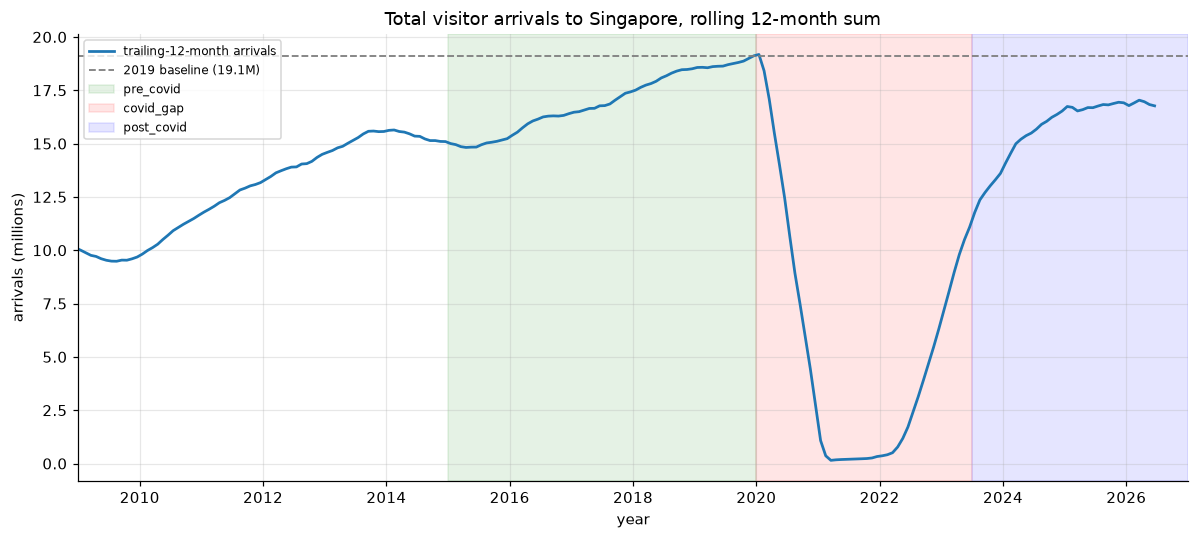

In [37]:
def yearly_sums(df, series_name, years):
    sub = df.loc[df["series"].astype(str).eq(series_name)]
    yr = sub["date"].dt.year.to_numpy()
    v = sub["value"].to_numpy(dtype="float64")
    return np.array([v[yr == y].sum() for y in years], dtype="float64")

YEARS = np.arange(2008, 2027)
arr_annual = yearly_sums(iva, TOTAL_LABEL, YEARS)
def base(years=YEARS, arr=arr_annual):
    return float(arr[years == 2019][0])

print(f"2019 baseline arrivals: {base()/1e6:.3f}M")

def period_of(period_obj):
    y = period_obj.year
    if y <= 2019:
        return "pre_covid"
    if y == 2023 and period_obj.quarter < 3:
        return "covid_gap"
    if y in (2020, 2021, 2022):
        return "covid_gap"
    return "post_covid"

print("Regime windows chosen:")
print("  pre_covid  : 2015-2019 (stable normal)")
print("  covid_gap  : 2020 - Q2-2023 (excluded: disjointed behaviour)")
print("  post_covid : Q3-2023 - 2025 (reopened, structurally new)")


# markets for market-level comparisons: exclude TOTAL and Others
EXCL = {"TOTAL", "Others"}
_mkt_res = profiles["attractions"]["residence"].astype(str)
markets = sorted({m for m in _mkt_res if m not in EXCL})
print(f"[setup] {len(markets)} source markets for market-level comparisons")

# ---- total arrivals to Singapore: trailing-12-month sum (x-axis = years) ----
_tot = iva.loc[iva["series"].astype(str).eq(TOTAL_LABEL) & iva["level"].eq("total")]
_ty = _tot["date"].dt.year.to_numpy(); _tm = _tot["date"].dt.month.to_numpy()
_tv = _tot["value"].to_numpy(dtype="float64")
_tpos = _ty + (_tm - 0.5) / 12
_roll = (pd.Series(_tv, index=pd.PeriodIndex(_tot["date"], freq="M"))
         .sort_index().rolling(12, min_periods=1).sum() / 1e6)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(_tpos, _roll.to_numpy(), lw=1.8, color="#1f77b4",
        label="trailing-12-month arrivals")
ax.axhline(base()/1e6, color="gray", ls="--", lw=1.2,
           label=f"2019 baseline ({base()/1e6:.1f}M)")
ax.axvspan(2015, 2019.999, color="green", alpha=0.10, label="pre_covid")
ax.axvspan(2020, 2023.499, color="red", alpha=0.10, label="covid_gap")
ax.axvspan(2023.5, 2027, color="blue", alpha=0.10, label="post_covid")
ax.set_title("Total visitor arrivals to Singapore, rolling 12-month sum")
ax.set_xlabel("year"); ax.set_ylabel("arrivals (millions)")
ax.set_xlim(2009, 2027)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

using 2019 has baseline because its the last "normal" pre covid year, and arrivals were peaking.

I chose Q3 2023 as the post‑COVID regime start because it represents the first clean window when the travel system had structurally stabilised. While Singapore removed its vaccinated travel pass (VTP) requirements in April 2022, that year remained a transitional period: revenge travel was still distorting demand, flight capacity had not fully recovered, and China did not reopen its borders until January 2023. The subsequent two quarters (Q1–Q2 2023) were also unsuitable because they captured the catch‑up surge from China’s reopening—a temporary demand spike rather than steady‑state behaviour. By Q3 2023, the surge had subsided, flight capacity was broadly restored, and the system was operating under genuinely “normal” conditions for the first time since 2019. I did not use an earlier date (e.g., Q1 2024) because that would have discarded two quarters of post‑recovery signal from late 2023, reducing the statistical power of the interrupted time‑series analysis without a clear benefit.

# **Exploration**

## **Arrivals**

As per the 12 month rolling arrivals graph above, arrivals are no longer recovering: 2019 = 19.12 M, 2024 = 16.53 M, 2025 = 16.91 M (still 11.5% below the pre-COVID peak), and the rolling-12-month series has been flat since ~mid-2024.


## **Receipts**

Nominal vs CPI-deflated (2019-S$) receipts:

   y  receipts_bn  per_arr  real_receipts_bn  real_per_arr
2014         23.6   1560.8              23.7        1569.0
2015         21.8   1429.7              22.0        1444.8
2016         25.7   1569.7              26.2        1594.7
2017         26.8   1538.5              27.1        1554.0
2018         26.9   1455.7              27.1        1463.9
2019         27.7   1448.5              27.7        1448.5
2020          4.8   1761.2               4.8        1764.2
2021          1.9   5738.4               1.9        5618.1
2022         14.2   2248.4              13.1        2074.2
2023         27.2   1996.4              23.9        1756.8
2024         29.8   1802.0              25.6        1548.7
2025         32.8   1936.7              27.9        1649.6

Nominal per-visitor 2019->2025: +33.7%
REAL per-visitor 2019->2025:    +13.9%  (CPI-deflated)


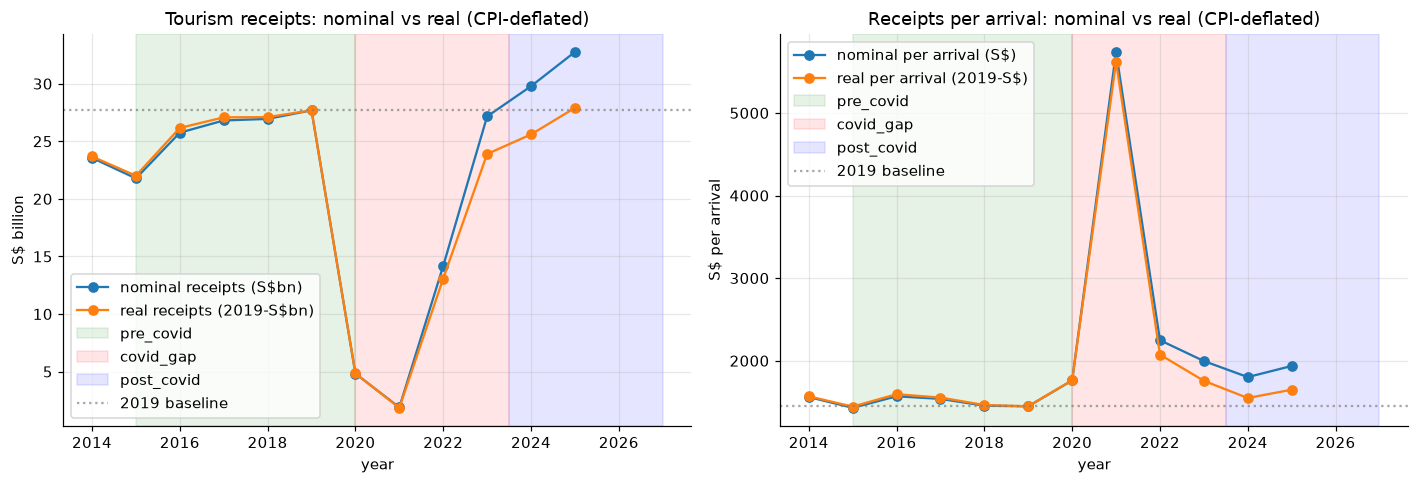

In [38]:
# --- 4.2 value: receipts per arrival, nominal and real (CPI-deflated) ----
# Receipts component data is quarterly-YTD. Annual = Q4 figure.
def annual_receipts(component, year):
    sub = receipts.loc[receipts["series"].astype(str).eq(component) &
                       receipts["date"].dt.year.eq(year) &
                       receipts["date"].dt.quarter.eq(4)]
    return float(sub["value"].sum()) if len(sub) else np.nan

# ---- CPI deflator (self-contained; same logic as the Q1 ·4 CPI cell) ----
_cpi_path = os.path.join("other data", "cpi_monthly.csv")
cpi = pd.read_csv(_cpi_path, usecols=["date", "cpi"])
cpi["date"] = pd.to_datetime(cpi["date"].astype(str) + "-01")
cpi = cpi.loc[(cpi["date"].dt.year >= 2014) & (cpi["date"].dt.year <= 2026)]
CPI_2019 = float(np.mean(cpi.loc[cpi.date.dt.year == 2019, "cpi"]))
cpi_y_mean = {y: float(np.mean(cpi.loc[cpi.date.dt.year == y, "cpi"]))
              for y in np.arange(2014, 2026)}

tot = {"y": [], "receipts_bn": [], "per_arr": [],
       "real_receipts_bn": [], "real_per_arr": []}
for y in np.arange(2014, 2026):
    r = annual_receipts("Tourism Receipts", y)   # S$ MILLION
    a = arr_annual[YEARS == y][0]                # actual arrivals
    tot["y"].append(int(y))
    receipts_bn = r / 1e3 if r == r else np.nan                    # million -> S$bn
    per_arr = r * 1e6 / a if (r == r and a > 0) else np.nan       # S$ per arrival
    tot["receipts_bn"].append(receipts_bn)
    tot["per_arr"].append(per_arr)
    cpi_y = cpi_y_mean.get(int(y))
    if receipts_bn == receipts_bn and cpi_y == cpi_y:
        tot["real_receipts_bn"].append(receipts_bn * CPI_2019 / cpi_y)   # 2019-S$bn
        tot["real_per_arr"].append(per_arr * CPI_2019 / cpi_y)           # 2019-S$ per arrival
    else:
        tot["real_receipts_bn"].append(np.nan)
        tot["real_per_arr"].append(np.nan)

value = pd.DataFrame(tot)
print("Nominal vs CPI-deflated (2019-S$) receipts:\n")
print(value.round(1).to_string(index=False))
n25 = value.loc[value.y == 2025, "per_arr"].iloc[0]
r25 = value.loc[value.y == 2025, "real_per_arr"].iloc[0]
print(f"\nNominal per-visitor 2019->2025: {(n25/value.loc[value.y==2019,'per_arr'].iloc[0]-1)*100:+.1f}%")
print(f"REAL per-visitor 2019->2025:    {(r25/value.loc[value.y==2019,'real_per_arr'].iloc[0]-1)*100:+.1f}%  (CPI-deflated)")

# Regime shading
def _regimes(ax):
    ax.axvspan(2015, 2019.999, color="green", alpha=0.10, label="pre_covid")
    ax.axvspan(2020, 2023.499, color="red", alpha=0.10, label="covid_gap")
    ax.axvspan(2023.5, 2027, color="blue", alpha=0.10, label="post_covid")

# Total receipts (S$bn): nominal blue + real orange, with regimes
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(value["y"], value["receipts_bn"], "-o", color="#1f77b4", label="nominal receipts (S$bn)")
ax.plot(value["y"], value["real_receipts_bn"], "-o", color="#ff7f0e", label="real receipts (2019-S$bn)")
_regimes(ax)

# --- ADD GREY 2019 BASELINE ---
baseline_receipts = value.loc[value.y == 2019, 'receipts_bn'].iloc[0]
ax.axhline(y=baseline_receipts, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='2019 baseline')
# ------------------------------

ax.set_title("Tourism receipts: nominal vs real (CPI-deflated)")
ax.set_xlabel("year"); ax.set_ylabel("S$ billion"); ax.legend()

# Receipts per arrival (S$): nominal blue + real orange, with regimes
ax = axes[1]
ax.plot(value["y"], value["per_arr"], "-o", color="#1f77b4", label="nominal per arrival (S$)")
ax.plot(value["y"], value["real_per_arr"], "-o", color="#ff7f0e", label="real per arrival (2019-S$)")
_regimes(ax)

# --- ADD GREY 2019 BASELINE ---
baseline_per_arr = value.loc[value.y == 2019, 'per_arr'].iloc[0]
ax.axhline(y=baseline_per_arr, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='2019 baseline')
# ------------------------------

ax.set_title("Receipts per arrival: nominal vs real (CPI-deflated)")
ax.set_xlabel("year"); ax.set_ylabel("S$ per arrival"); ax.legend()

plt.tight_layout(); plt.show()

The spike in receipts per arrival in 2021 is due to drastic denominator changes. Arrivals collapsed 88% from 2.7M to 0.33M, while receipts only fell 60% ($4.8B to $1.9B). The few visitors who could enter were business travellers and VTL passengers. They were disproportionately high-spenders, while low-spending mass-market tourists were largely absent. This skewed the average spend upward.

Nominal tourism recipts grew, but looking at real figures, 2025 looked about the same as in 2019. Nominal per-visitor rose ~+34% 2019→2025, but real per-visitor rose only ~+14% once deflated by the CPI. The increase is far smaller in real terms which makes sense since total arrival in 2025 (16.91 mil) was less than 2019 (19.12 mil)

## **Receipts components**

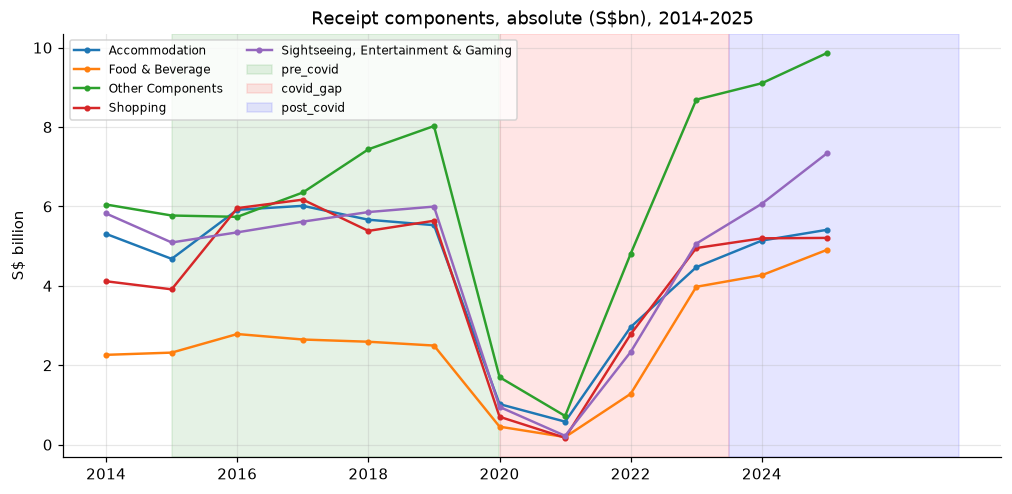

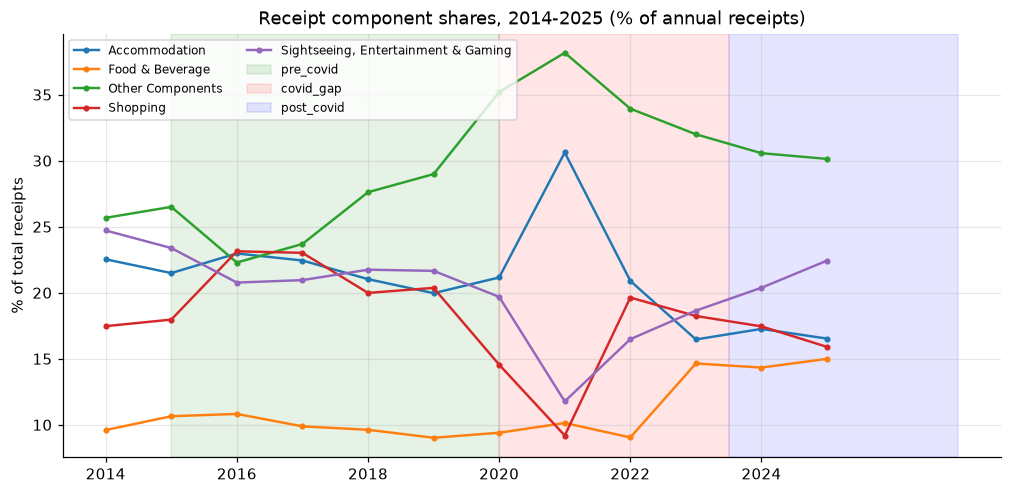

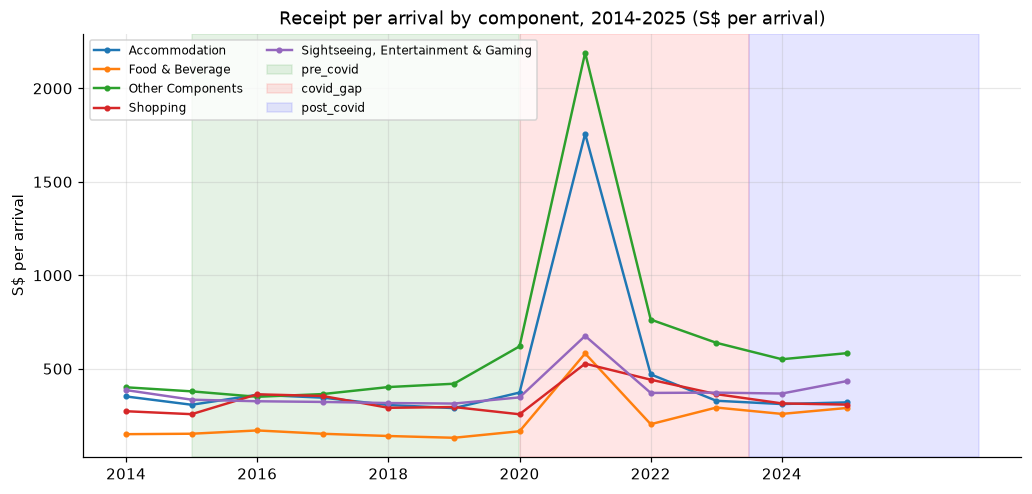

Component share moves 2019 -> 2025 (pp):
                         Food & Beverage: +6.0
                        Other Components: +1.1
     Sightseeing, Entertainment & Gaming: +0.8
                           Accommodation: -3.4
                                Shopping: -4.5


In [39]:
rq = receipts.loc[receipts["series"].astype(str).eq("Tourism Receipts")]
rq_y = rq["date"].dt.year.to_numpy()
rq_q = rq["date"].dt.quarter.to_numpy()
rq_v = rq["value"].to_numpy(dtype="float64")

cq = receipts.loc[receipts["level"].ne("total")]
comp_names = sorted(cq["series"].unique().tolist())
cn = cq["series"].to_numpy()
cy = cq["date"].dt.year.to_numpy()
cqq = cq["date"].dt.quarter.to_numpy()
cvv = cq["value"].to_numpy(dtype="float64")

RC_YEARS = np.arange(2014, 2026)
abs_mat = np.full((len(comp_names), len(RC_YEARS)), np.nan)
share_mat = np.full((len(comp_names), len(RC_YEARS)), np.nan)
per_arr_mat = np.full((len(comp_names), len(RC_YEARS)), np.nan)
for i, cname in enumerate(comp_names):
    for j, yy in enumerate(RC_YEARS):
        tt = float(rq_v[(rq_y == int(yy)) & (rq_q == 4)].sum())
        pp = float(cvv[(cn == cname) & (cy == int(yy)) & (cqq == 4)].sum())
        aa = float(arr_annual[YEARS == int(yy)][0])
        abs_mat[i, j] = pp / 1e3            # S$bn
        if tt > 0:
            share_mat[i, j] = pp / tt * 100 # % of total receipts
        if aa > 0:
            per_arr_mat[i, j] = pp * 1e6 / aa  # S$ per arrival

def _regimes(ax):
    ax.axvspan(2015, 2019.999, color="green", alpha=0.10, label="pre_covid")
    ax.axvspan(2020, 2023.499, color="red", alpha=0.10, label="covid_gap")
    ax.axvspan(2023.5, 2027, color="blue", alpha=0.10, label="post_covid")

# 1) absolute amount (S$bn)
fig, ax = plt.subplots(figsize=(11, 5))
for i, cname in enumerate(comp_names):
    ax.plot(RC_YEARS, abs_mat[i], marker="o", ms=3, lw=1.6, label=cname)
_regimes(ax)
ax.set_xticks(range(2014, 2026, 2))
ax.set_title("Receipt components, absolute (S$bn), 2014-2025")
ax.set_ylabel("S$ billion")
ax.legend(fontsize=8, loc="upper left", ncols=2)
plt.show()

# 2) % of total receipts
fig, ax = plt.subplots(figsize=(11, 5))
for i, cname in enumerate(comp_names):
    ax.plot(RC_YEARS, share_mat[i], marker="o", ms=3, lw=1.6, label=cname)
_regimes(ax)
ax.set_xticks(range(2014, 2026, 2))
ax.set_title("Receipt component shares, 2014-2025 (% of annual receipts)")
ax.set_ylabel("% of total receipts")
ax.legend(fontsize=8, loc="upper left", ncols=2)
plt.show()

# 3) per arrival (S$ per arrival)
fig, ax = plt.subplots(figsize=(11, 5))
for i, cname in enumerate(comp_names):
    ax.plot(RC_YEARS, per_arr_mat[i], marker="o", ms=3, lw=1.6, label=cname)
_regimes(ax)
ax.set_xticks(range(2014, 2026, 2))
ax.set_title("Receipt per arrival by component, 2014-2025 (S$ per arrival)")
ax.set_ylabel("S$ per arrival")
ax.legend(fontsize=8, loc="upper left", ncols=2)
plt.show()

j19, j25 = int(np.where(RC_YEARS == 2019)[0][0]), int(np.where(RC_YEARS == 2025)[0][0])
moves = sorted(((c, float(share_mat[i, j25] - share_mat[i, j19]))
                for i, c in enumerate(comp_names)), key=lambda t: -t[1])
print("Component share moves 2019 -> 2025 (pp):")
for c, d in moves:
    print(f"  {c:>38}: {d:+.1f}")

### behaviour during covid

During the COVID period (2020–2023), the absolute values of every spending component collapsed because global travel bans and border closures reduced arrivals to near‑zero. However, the composition and ratios of spending shifted in ways that reveal the extreme asymmetry of who was still travelling.

The few visitors who entered Singapore during 2021 were predominantly essential business travellers, returning residents, and Vaccinated Travel Lane (VTL) passengers. These travellers were legally required or practically compelled to stay in formal hotels, often for extended quarantine periods or long‑term assignments, which inflated the proportion of total spending allocated to accommodation. With mass‑market leisure tourists absent, the denominator (total receipts) was so small that accommodation's share of that shrinking pie jumped to ~35%, despite its absolute value being a fraction of 2019 levels.

Mass‑market leisure travel, which typically drives spending on attractions, nightlife, and retail, was virtually non‑existent. The few travellers who did come were less likely to visit crowded attractions or make discretionary retail purchases. With the denominator dominated by essential hotel stays, the relative shares of SEG and Shopping fell sharply, even though their absolute dollar declines were also severe.

Food and beverage spending is a non‑discretionary component of travel—travellers must eat regardless of purpose. Even essential or stranded travellers still purchased meals, which cushioned F&B's decline compared to accommodation and retail. Its share of the tiny receipts pie remained stable because it was tied to daily living needs rather than leisure‑dependent activities.

The ratio (per‑arrival accommodation cost) spiked dramatically in 2021 because the composition of arrivals skewed toward long‑stay, high‑spending business travellers, while the total number of arrivals was minuscule. This was a denominator issue. Once mass‑market leisure resumed, the ratio reverted toward its long‑term average, reinforcing that the spike was a temporary statistical anomaly.

### "normal" periods, pre n post covid

Accommodation spending fell sharply during COVID and has been slow to rebound because business travel and large‑scale MICE events, which drove high hotel occupancy, have not fully returned. The rise in remote work and hybrid meetings structurally reduced corporate travel demand. Food & Beverage and Sightseeing, Entertainment & Gaming (SEG) recovered more quickly because they are tied to leisure and local experiences, which rebounded faster as borders reopened. Shopping spending recovered strongly by 2024, driven by luxury tax‑free purchases from high‑spending tourists (especially from China and Indonesia), but its recovery remains volatile and dependent on tourist volumes and retail policy.

FnB increased since covid. Other trendlines are too volatile to make a judgement. More investigation needed

## **Arrivals by Country**

In [40]:
# ---- Arrivals by country over time (annual): top 5 gainers & top 5 decliners vs 2019 baseline ----
mkt = iva.loc[iva["level"].eq("item")].copy()
mkt_names = mkt["series"].astype(str).to_numpy()
mkt_yr = mkt["date"].dt.year.to_numpy()
mkt_v = mkt["value"].to_numpy(dtype="float64")

C_YEARS = np.arange(2019, 2026)          # graphs start from 2014
ann = {}
for m in np.unique(mkt_names):
    ann[m] = np.array([mkt_v[(mkt_names == m) & (mkt_yr == y)].sum()
                       for y in C_YEARS], dtype="float64")
total_ann = np.array([mkt_v[mkt_yr == y].sum() for y in C_YEARS], dtype="float64")

i19, i25 = int(np.where(C_YEARS == 2019)[0][0]), int(np.where(C_YEARS == 2025)[0][0])
delta = {m: float(ann[m][i25] - ann[m][i19]) for m in ann}
gainers = sorted(delta, key=delta.get, reverse=True)[:5]
decliners = sorted(delta, key=delta.get)[:5]
pick = gainers + decliners

print("Top 5 gainers vs 2019 baseline (2025 - 2019, abs change in arrivals):")
for m in gainers:
    print(f"  {m:>34}: {delta[m]/1e3:+.3f}k")
print("Top 5 decliners vs 2019 baseline (2025 - 2019, abs change in arrivals):")
for m in decliners:
    print(f"  {m:>34}: {delta[m]/1e3:+.3f}k")

Top 5 gainers vs 2019 baseline (2025 - 2019, abs change in arrivals):
                           Australia: +124.124k
                            Malaysia: +54.664k
             Other Markets In Europe: +48.033k
                United Arab Emirates: +21.007k
                          Bangladesh: +19.973k
Top 5 decliners vs 2019 baseline (2025 - 2019, abs change in arrivals):
                           Indonesia: -670.781k
                               China: -526.964k
                               Japan: -256.795k
                             Vietnam: -247.658k
                               India: -210.793k


In [41]:
# ---- China & Indonesia share of total arrivals: 2019 vs 2025 ----
_mk = iva.loc[iva["level"].eq("item")]
_mn = _mk["series"].astype(str).to_numpy()
_my = _mk["date"].dt.year.to_numpy()
_mv = _mk["value"].to_numpy(dtype="float64")

for y in (2019, 2025):
    yy = _my == int(y)
    tot = float(_mv[yy].sum())
    print(f"{y} total arrivals: {tot/1e6:.3f}M")
    for m in ("China", "Indonesia"):
        v = float(_mv[(_mn == m) & yy].sum())
        print(f"  {m:>10}: {v/1e6:.3f}M  =  {v/tot*100:.1f}% of total")
    print()

2019 total arrivals: 19.116M
       China: 3.627M  =  19.0% of total
   Indonesia: 3.111M  =  16.3% of total

2025 total arrivals: 16.912M
       China: 3.100M  =  18.3% of total
   Indonesia: 2.440M  =  14.4% of total



Arrivals by nationality (2019 -> 2025):
                                      2019       2025  share19  share25  delta
China                            3627120.0  3100156.0     19.0     18.3  -14.5
Indonesia                        3110626.0  2439845.0     16.3     14.4  -21.6
Malaysia                         1220730.0  1275394.0      6.4      7.5    4.5
Australia                        1143336.0  1267460.0      6.0      7.5   10.9
India                            1417993.0  1207200.0      7.4      7.1  -14.9
Philippines                       829325.0   726091.0      4.3      4.3  -12.4
USA                               729409.0   716973.0      3.8      4.2   -1.7
Japan                             884308.0   627513.0      4.6      3.7  -29.0
United Kingdom                    607821.0   587359.0      3.2      3.5   -3.4
South Korea                       645848.0   587010.0      3.4      3.5   -9.1
Taiwan                            425629.0   422688.0      2.2      2.5   -0.7
Thailand    

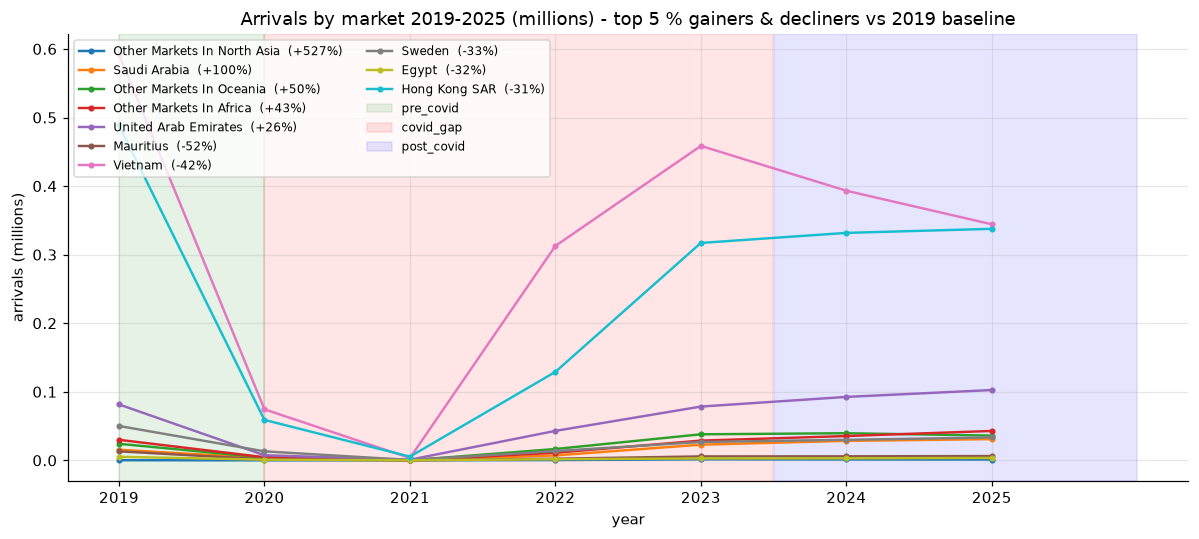

In [42]:
_mkt = iva.loc[iva["level"].eq("item")].copy()
_mkt_n = _mkt["series"].astype(str).to_numpy()
_mkt_y = _mkt["date"].dt.year.to_numpy()
_mkt_v = _mkt["value"].to_numpy(dtype="float64")
def _mkt_year(name, year):
    sel = (_mkt_n == name) & (_mkt_y == int(year))
    return float(_mkt_v[sel].sum()) if sel.any() else 0.0

_mkt_unique = sorted(set(_mkt_n))
year19 = {m: _mkt_year(m, 2019) for m in _mkt_unique}
year25 = {m: _mkt_year(m, 2025) for m in _mkt_unique}
comp = pd.DataFrame({"2019": year19, "2025": year25}).sort_values("2025", ascending=False)
comp = comp.loc[comp["2025"] > 0].copy()
comp["share19"] = comp["2019"] / comp["2019"].sum() * 100
comp["share25"] = comp["2025"] / comp["2025"].sum() * 100
# delta = % change vs 2019 baseline: (2025-2019)/|2019| * 100
comp["delta"] = (comp["2025"] - comp["2019"]) / comp["2019"].abs() * 100
comp = comp.loc[comp["2019"] > 0].copy()
print("Arrivals by nationality (2019 -> 2025):")
print(comp.round(1).to_string())
print("\nLargest % gainers:", ", ".join(comp.sort_values('delta', ascending=False).head(4).index))
print("Largest % losers :", ", ".join(comp.sort_values('delta').head(4).index))
print("\nOnly these markets grew in BOTH share and % terms:",
      ", ".join(comp[(comp['delta'] > 0) & (comp['share25'] > comp['share19'])].index))

# ---- top 5 positive & top 5 negative %-changers: annual arrivals line, 2019-2025 ----
g_top = comp.sort_values('delta', ascending=False).head(5).index.tolist()
d_top = comp.sort_values('delta').head(5).index.tolist()
pick = g_top + d_top
P_YEARS = np.arange(2019, 2026)
def _p_year(name, year):
    return _mkt_year(name, year)
ann_series = {m: np.array([_p_year(m, y) / 1e6 for y in P_YEARS]) for m in pick}

def _regimes(ax):
    ax.axvspan(2019, 2019.999, color="green", alpha=0.10, label="pre_covid")
    ax.axvspan(2020, 2023.499, color="red", alpha=0.10, label="covid_gap")
    ax.axvspan(2023.5, 2025.999, color="blue", alpha=0.10, label="post_covid")

_cmap = plt.get_cmap("tab10")
pick_colors = {m: _cmap(i % 10) for i, m in enumerate(pick)}
fig, ax = plt.subplots(figsize=(11, 5))
for m in pick:
    ax.plot(P_YEARS, ann_series[m], marker="o", ms=3, lw=1.6,
            color=pick_colors[m], label=f"{m}  ({comp.loc[m,'delta']:+.0f}%)")
_regimes(ax)
ax.set_xticks(range(2019, 2026))
ax.set_title("Arrivals by market 2019-2025 (millions) - top 5 % gainers & decliners vs 2019 baseline")
ax.set_xlabel("year"); ax.set_ylabel("arrivals (millions)")
ax.legend(fontsize=8, loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

Smaller markets are recovering faster and, in many cases, growing well beyond 2019 levels. Markets such as Other North Asia, the UAE, and Saudi Arabia have shown strong percentage growth, while Vietnam and Mauritius remain lagging behind. The dramatic percentage increases (e.g., +527% for Other North Asia) reflect a low‑base effect—these markets were tiny before COVID, so even modest absolute growth appears large in percentage terms. Directionally, however, the pattern is clear: culturally proximate and premium markets are regaining momentum faster than long‑haul or price‑sensitive ones. This divergence supports the structural shift argument. Recovery is not uniform, and the faster‑growing smaller markets are those whose travel preferences align with uniquely Singaporean experiences. The absolute volumes remain small, so these markets are promising diversifiers, not replacements for the volume lost from larger source markets.

### **Seasonality in arrivals**

2025 top-5 source-market share: 54.9%


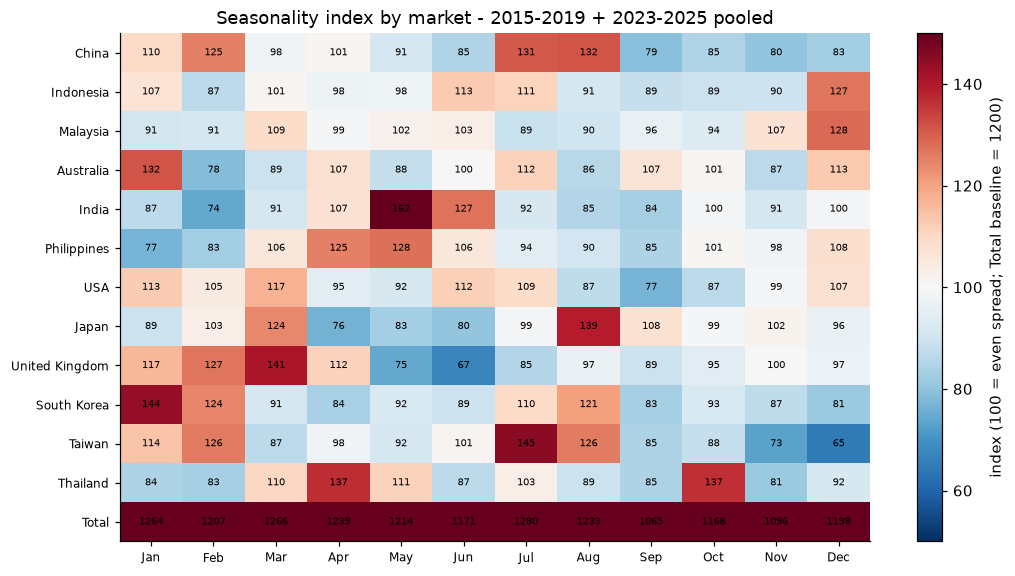

Most seasonal: India (87pts), Taiwan (80pts), United Kingdom (74pts)
China: peak month index 132 (month 8), Feb index 125
Month-of-year profile correlation pre vs post COVID: r=0.91 | peak month 7 -> 7


In [43]:
mkt = iva.loc[iva["level"].eq("item")]
mkt_names = mkt["series"].astype(str).to_numpy()
mkt_yr = mkt["date"].dt.year.to_numpy()
mkt_v = mkt["value"].to_numpy(dtype="float64")

top5_share = []
for y in np.arange(2008, 2026):
    yy = mkt_yr == int(y)
    if yy.sum() == 0:
        continue
    vals = mkt_v[yy]
    names = mkt_names[yy]
    ser = pd.Series(vals, index=names).groupby(level=0).sum()
    total = ser.sum()
    top5 = ser.sort_values(ascending=False).head(5).sum()
    top5_share.append((y, top5 / total * 100))
tdf = pd.DataFrame(top5_share, columns=["year", "top5_share"])
print(f"2025 top-5 source-market share: {tdf['top5_share'].iloc[-1]:.1f}%")

# ---- seasonality index per market (COVID years excluded) ----
sel = ~np.isin(mkt_yr, [2020, 2021, 2022])
mkt_mon = mkt["date"].dt.month.to_numpy()
def mkt_sum(name, year):
    return float(mkt_v[(mkt_names == name) & (mkt_yr == year)].sum())
top12 = sorted(set(mkt_names.tolist()), key=lambda s: mkt_sum(s, 2025),
               reverse=True)[:12]

seas = {}
for m in top12:
    mm = sel & (mkt_names == m)
    tot = float(mkt_v[mm].sum())
    shares = np.array([float(mkt_v[mm & (mkt_mon == k)].sum()) / tot * 100
                       for k in range(1, 13)])
    seas[m] = shares / (100 / 12) * 100

mat = np.array([seas[m] for m in top12])
# total per column = sum of the seasonality index across markets (baseline 12*100=1200 if all even)
tot_row = mat.sum(axis=0)
mat_t = np.vstack([mat, tot_row])
top12_t = top12 + ["Total"]
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(mat_t, cmap="RdBu_r", vmin=50, vmax=150, aspect="auto")
ax.set_yticks(range(len(top12_t)), top12_t, fontsize=8)
ax.set_xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], fontsize=8)
for i in range(mat_t.shape[0]):
    for j in range(mat_t.shape[1]):
        ax.text(j, i, f"{mat_t[i, j]:.0f}", ha="center", va="center", fontsize=6.5)
fig.colorbar(im, ax=ax, label="index (100 = even spread; Total baseline = 1200)")
ax.set_title("Seasonality index by market - 2015-2019 + 2023-2025 pooled")
ax.grid(False)
plt.show()

spreads = sorted(((m, float(seas[m].max() - seas[m].min())) for m in top12),
                 key=lambda t: -t[1])
print("Most seasonal:", ", ".join(f"{m} ({s:.0f}pts)" for m, s in spreads[:3]))
china = [m for m in top12 if m.startswith("China")][0]
cj = int(np.argmax(seas[china]))
print(f"{china}: peak month index {seas[china][cj]:.0f} "
      f"(month {cj + 1}), Feb index {seas[china][1]:.0f}")

# ---- did COVID flatten overall seasonality? pre vs post month-profile ----
mdf_all = iva.loc[iva["series"].eq(TOTAL_LABEL) & iva["level"].eq("total")]
tm_y = mdf_all["date"].dt.year.to_numpy()
tm_mo = mdf_all["date"].dt.month.to_numpy()
tm_v = mdf_all["value"].to_numpy(dtype="float64")

def moy_profile(yr_set):
    mm = np.isin(tm_y, yr_set)
    tot = float(tm_v[mm].sum())
    sh = np.array([float(tm_v[mm & (tm_mo == k)].sum()) / tot for k in range(1, 13)])
    return sh / sh.mean() * 100

pre_idx, post_idx = moy_profile((2015, 2016, 2017, 2018, 2019)), moy_profile(
    (2023, 2024, 2025))
r_flat = float(np.corrcoef(pre_idx, post_idx)[0, 1])
peak_pre = int(np.argmax(pre_idx)) + 1
peak_post = int(np.argmax(post_idx)) + 1
print(f"Month-of-year profile correlation pre vs post COVID: r={r_flat:.2f} | "
      f"peak month {peak_pre} -> {peak_post}")

The month-of-year timing barely changed. Total arrivals stay seasonal (pre/post month-profile correlation r ≈ 0.91, peak month 7 → 7). 


### Investigating if theres correlation to countries' temperature or holidays

Temperature from Open-Meteo ERA5 (archive-api.open-meteo.com, free, no key); holidays from the 'holidays' python package (official public-holiday calendars, offline after pip install). School-holiday counts are region-average approximations from the internet, not official data. Data cells cache results to other data/ for offline re-runs.



In [44]:
import urllib.request, urllib.parse
import calendar
import datetime
import holidays as _holidays

CAPITALS = {
    "China":      (39.9042, 116.4074, "Beijing"),
    "India":      (28.6139, 77.2090,  "New Delhi"),
    "United Kingdom": (51.5074, -0.1278, "London"),
    "Thailand":   (13.7563, 100.5018, "Bangkok"),
    "South Korea":(37.5665, 126.9780, "Seoul"),
}
HOL_CLS = {"China": _holidays.China, "India": _holidays.India,
           "United Kingdom": _holidays.UK, "Thailand": _holidays.Thailand,
           "South Korea": _holidays.SouthKorea}
TEMP_YEARS = (2015, 2016, 2017, 2018, 2019, 2023, 2024, 2025)   # non-COVID, matches seasonality cell
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
MKT_ORDER = ["China", "India", "United Kingdom", "Thailand", "South Korea"]
TEMP_COLORS = {"China": "#D80303", "India": "#ff00ff",
               "United Kingdom": "#1f77b4", "Thailand": "#2ca02c",
               "South Korea": "#9467bd"}


[temp] loaded cached other data\temp_capital_monthly.csv


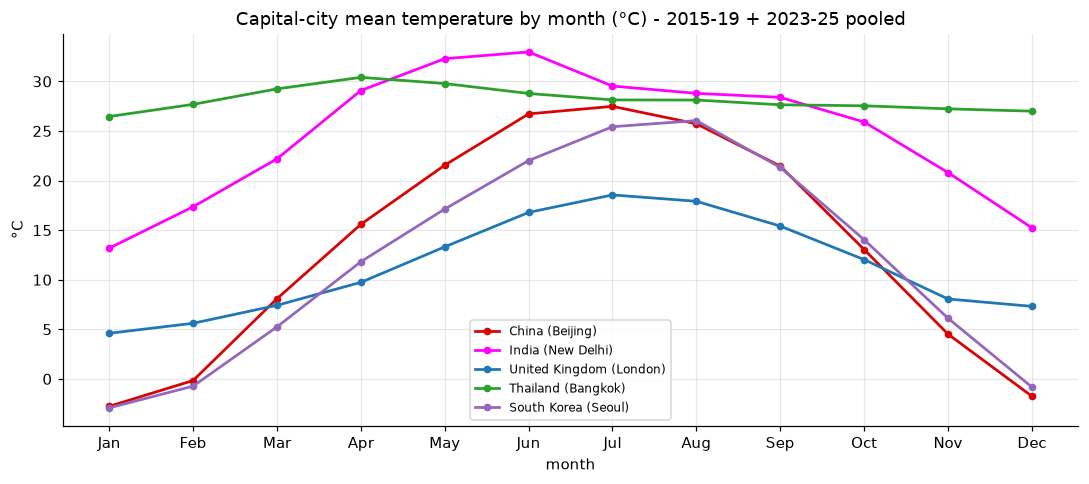

In [45]:
# ---- Temperature data (Open-Meteo) + plot ----
_temp_cache = os.path.join("other data", "temp_capital_monthly.csv")
if os.path.exists(_temp_cache):
    temp_df = pd.read_csv(_temp_cache)
    print(f"[temp] loaded cached {_temp_cache}")
else:
    lats = ",".join(str(c[0]) for c in CAPITALS.values())
    lons = ",".join(str(c[1]) for c in CAPITALS.values())
    q = urllib.parse.urlencode({"latitude": lats, "longitude": lons,
                                "start_date": "2015-01-01", "end_date": "2025-12-31",
                                "daily": "temperature_2m_mean", "timezone": "auto",
                                "temperature_unit": "celsius"})
    url = f"https://archive-api.open-meteo.com/v1/archive?{q}"
    resp = json.loads(urllib.request.urlopen(url, timeout=60).read().decode())
    rows = []
    for mk, loc in zip(CAPITALS, resp):
        dtimes = loc["daily"]["time"]
        dtemp = loc["daily"]["temperature_2m_mean"]
        for t, v in zip(dtimes, dtemp):
            if v is None: continue
            y, mo = int(t[:4]), int(t[5:7])
            rows.append((mk, y, mo, float(v)))
    temp_df = pd.DataFrame(rows, columns=["market", "year", "month", "tmean"])
    temp_df = temp_df.loc[temp_df.year.isin(TEMP_YEARS)]
    temp_df = temp_df.groupby(["market", "month"], as_index=False)["tmean"].mean()
    temp_df.to_csv(_temp_cache, index=False)
    print(f"[temp] fetched + cached {_temp_cache}")

fig, ax = plt.subplots(figsize=(10, 4.5))
for mk in MKT_ORDER:
    sub = temp_df.loc[temp_df.market == mk]
    ax.plot(sub["month"], sub["tmean"], "-o", ms=4, lw=1.8,
            color=TEMP_COLORS[mk], label=f"{mk} ({CAPITALS[mk][2]})")
ax.set_xticks(range(1, 13), MONTHS)
ax.set_title("Capital-city mean temperature by month (°C) - 2015-19 + 2023-25 pooled")
ax.set_xlabel("month"); ax.set_ylabel("°C"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


[hol] loaded cached other data\holiday_monthly.csv


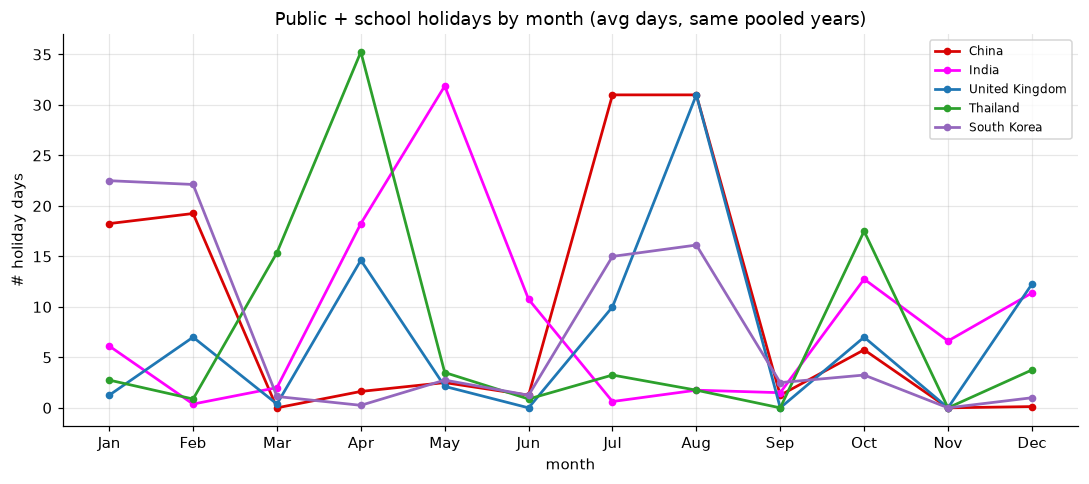

In [46]:
# ---- Holiday data (public + school) + plot ----
# Public holidays: official 'holidays' package, averaged over pooled years.
# School holidays: region-average approximations (not official data).
SCHOOL_HOL = {
    "China":          {1: 15, 2: 15, 7: 31, 8: 31},
    "India":          {1: 5, 4: 15, 5: 31, 6: 10, 10: 10, 11: 5, 12: 10},
    "United Kingdom": {2: 7, 4: 14, 7: 10, 8: 31, 10: 7, 12: 10},
    "Thailand":       {3: 15, 4: 30, 10: 15},
    "South Korea":    {1: 20, 2: 20, 7: 15, 8: 15},
}

_hol_cache = os.path.join("other data", "holiday_monthly.csv")
if os.path.exists(_hol_cache):
    hol_df = pd.read_csv(_hol_cache)
    print(f"[hol] loaded cached {_hol_cache}")
else:
    pub_cals = {mk: cls(years=range(2015, 2027)) for mk, cls in HOL_CLS.items()}
    hol_rows = []
    for mk, cal in pub_cals.items():
        for y in range(2015, 2026):
            if y not in TEMP_YEARS:
                continue
            for m in range(1, 13):
                n_pub = sum(1 for d in range(1, calendar.monthrange(y, m)[1] + 1)
                            if datetime.date(y, m, d) in cal)
                n_sch = SCHOOL_HOL[mk].get(m, 0)
                hol_rows.append((mk, y, m, n_pub, n_sch))
    hol_df = pd.DataFrame(hol_rows,
                          columns=["market", "year", "month", "public_holidays", "school_holidays"])
    hol_df = hol_df.groupby(["market", "month"], as_index=False).agg(
        public_holidays=("public_holidays", "mean"),
        school_holidays=("school_holidays", "mean"))
    hol_df["holidays"] = hol_df["public_holidays"] + hol_df["school_holidays"]
    hol_df.to_csv(_hol_cache, index=False)
    print(f"[hol] computed + cached {_hol_cache}")

fig, ax = plt.subplots(figsize=(10, 4.5))
for mk in MKT_ORDER:
    sub = hol_df.loc[hol_df.market == mk]
    ax.plot(sub["month"], sub["holidays"], "-o", ms=4, lw=1.8,
            color=TEMP_COLORS[mk], label=mk)
ax.set_xticks(range(1, 13), MONTHS)
ax.set_title("Public + school holidays by month (avg days, same pooled years)")
ax.set_xlabel("month"); ax.set_ylabel("# holiday days"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


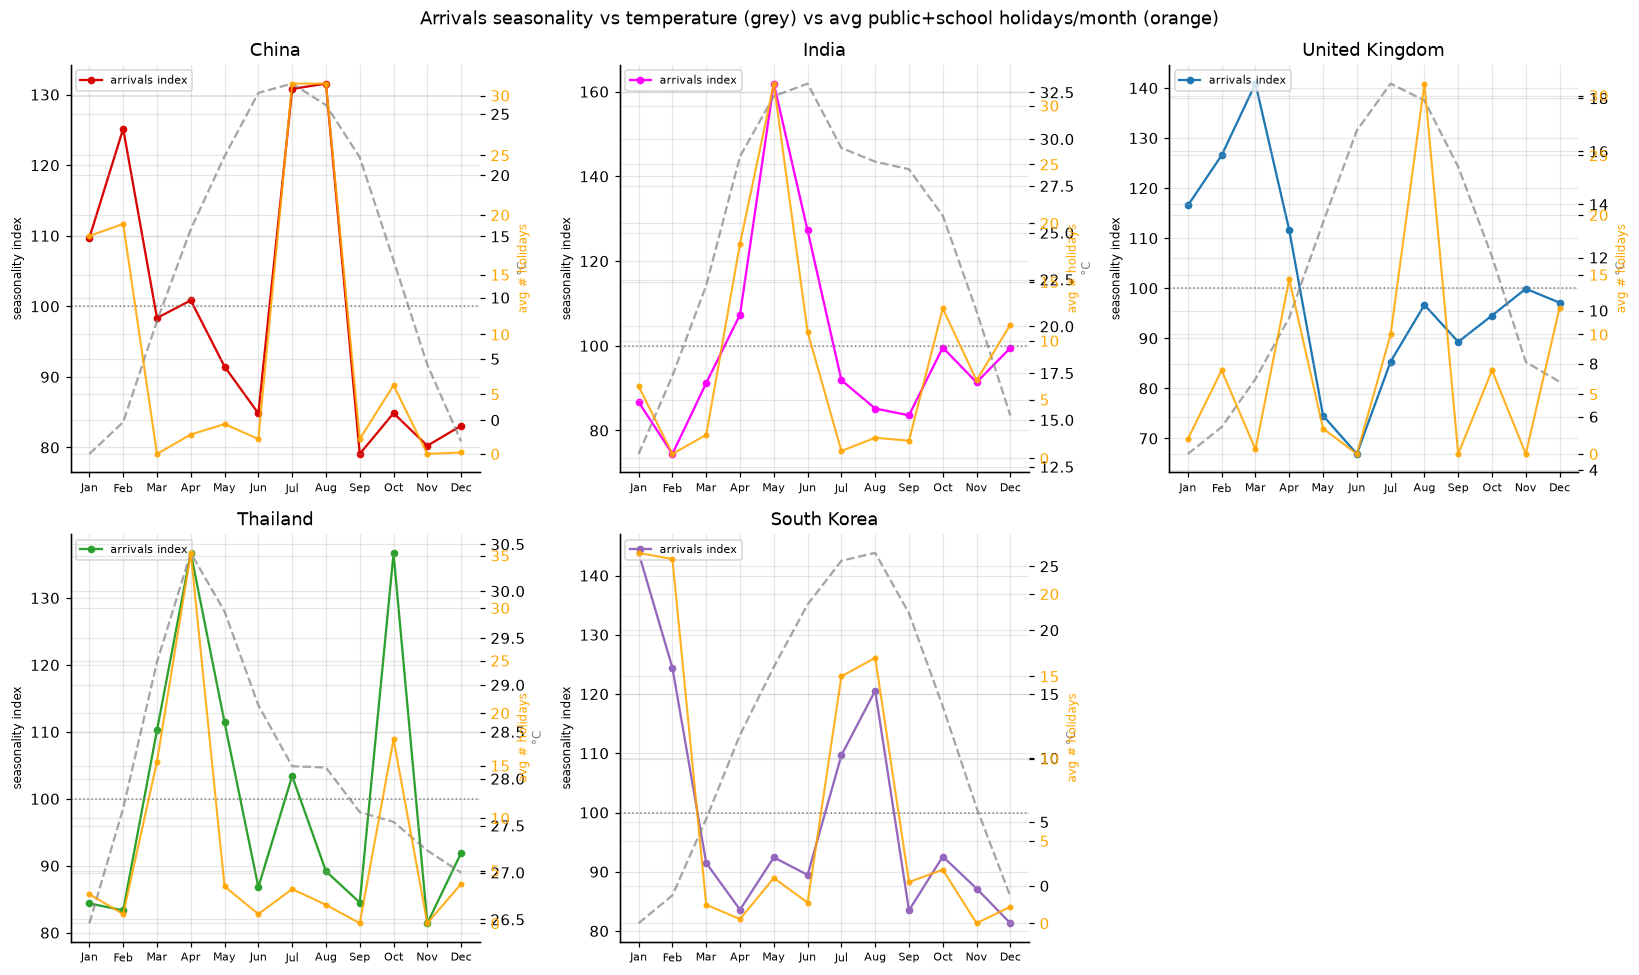

In [47]:
# ---- Correspondence: arrivals seasonality index vs temperature vs holidays ----
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, mk in zip(axes.ravel(), MKT_ORDER + [None]):
    if mk is None:
        ax.axis("off"); continue
    idx = seas.get(mk)
    if idx is None:
        continue
    months = np.arange(1, 13)
    ax.plot(months, idx, "-o", ms=4, color=TEMP_COLORS[mk], label="arrivals index")
    ax.axhline(100, color="grey", ls=":", lw=1)
    ax2 = ax.twinx()
    tsub = temp_df.loc[temp_df.market == mk]
    hsub = hol_df.loc[hol_df.market == mk]
    ax2.plot(months, tsub["tmean"], "--", color="grey", alpha=0.7, label="mean temp (°C)")
    ax2.set_ylabel("°C", color="grey", fontsize=8)
    ax3 = ax.twinx()
    ax3.plot(months, hsub["holidays"], "-o", ms=3, lw=1.4, color="orange", alpha=0.85,
             label="avg # holidays/month")
    ax3.set_ylabel("avg # holidays", color="orange", fontsize=8)
    ax3.tick_params(axis="y", labelcolor="orange")
    ax.set_title(mk)
    ax.set_xticks(months, MONTHS, fontsize=7)
    ax.set_ylabel("seasonality index", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Arrivals seasonality vs temperature (grey) vs avg public+school holidays/month (orange)")
fig.tight_layout(); plt.show()


Interestingly (or perhaps to be expectedly) the arrival indexes per country correspond closely to that nations' holiday calendar.

More interestingly, is that peaks in arrivals index correspond somewhat to extreme temperatures (see China and South Korea specifically. others less so)

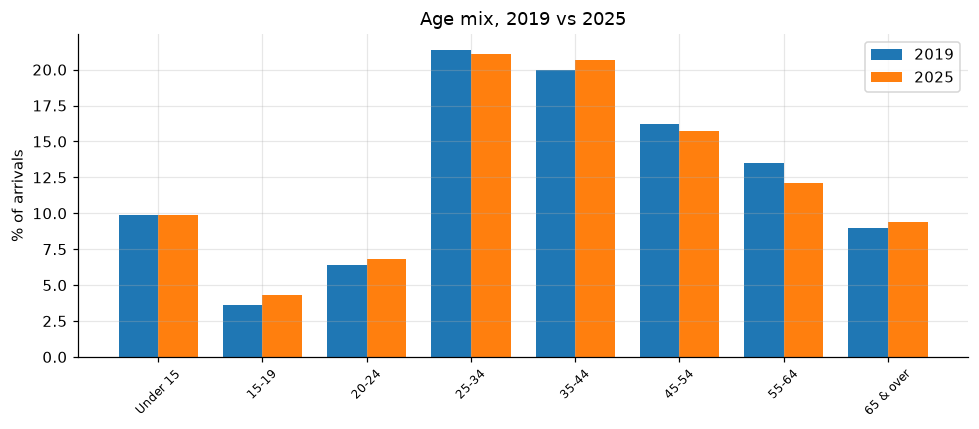

In [48]:
age_mix = {
    "Under 15": (9.9, 9.9), "15-19": (3.6, 4.3), "20-24": (6.4, 6.8),
    "25-34": (21.4, 21.1), "35-44": (20.0, 20.7), "45-54": (16.2, 15.7),
    "55-64": (13.5, 12.1), "65 & over": (9.0, 9.4),
}
a19 = [v[0] for v in age_mix.values()]; a25 = [v[1] for v in age_mix.values()]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(age_mix)); w = 0.38
ax.bar(x - w/2, a19, w, label="2019"); ax.bar(x + w/2, a25, w, label="2025")
ax.set_xticks(x); ax.set_xticklabels(age_mix.keys(), rotation=45, fontsize=8)
ax.set_ylabel("% of arrivals"); ax.set_title("Age mix, 2019 vs 2025")
ax.legend(); plt.tight_layout(); plt.show()

put disclaimer that the tiering is i put one, because literature. put these subjective things below, put objective things on top

## **uniqueness of singaporean experience**

Standard sectoral classifications (e.g., "attractions" or "shopping") do not capture what makes a venue distinctly Singaporean or why tourists might prioritise it over generic alternatives. To test whether uniqueness itself predicts post‑COVID recovery, I constructed a tiering variable that distinguishes highly local, culturally embedded venues (Tier‑3) from more generic or spectacle‑driven ones (Tier‑1 and Tier‑2). This classification is grounded in both the sense‑of‑place literature and my own behavioural data: it reflects the degree to which a venue offers experiences that are hard to substitute elsewhere, which prior research shows is a key driver of destination fascination and revisit intention (Jarratt et al., 2019; Liu et al., 2017). 

In [49]:
sg_tier = {
    "Chinatown": 3, "Little India": 3, "Raffles Hotel": 3, "Merlion Park": 3,
    "Singapore River": 3, "Singapore Botanic Gardens": 3,
    "Esplanade Theatres by the Bay": 2, "Gardens by the Bay": 2,
    "Orchard Road": 2, "National Orchid Gardens": 2,
    "Integrated Resort (MBS/RWS)": 1, "Sentosa": 1,
    "Singapore Flyer/ Flight Experience": 1, "Singapore Zoo": 1,
    "Night Safari": 1, "River Wonders (formerly River Safari)": 1,
    "Bird Paradise (formerly Jurong Bird Park)": 1,
}
sg_label = {
    "Chinatown": "Heritage district", "Little India": "Heritage district",
    "Raffles Hotel": "Colonial icon", "Merlion Park": "National symbol",
    "Singapore River": "Riparian history",
    "Singapore Botanic Gardens": "UNESCO garden",
    "Esplanade Theatres by the Bay": "Performance arts",
    "Gardens by the Bay": "Supertrees (cloneable)", "Orchard Road": "Retail strip",
    "National Orchid Gardens": "Botanic showcase",
    "Integrated Resort (MBS/RWS)": "Casino resort (generic)",
    "Sentosa": "Beach resort (generic)",
    "Singapore Flyer/ Flight Experience": "Observation wheel (generic)",
    "Singapore Zoo": "Zoo (substitutable)",
    "Night Safari": "Wildlife park (substitutable)",
    "River Wonders (formerly River Safari)": "River zoo (generic)",
    "Bird Paradise (formerly Jurong Bird Park)": "Bird park (generic)",
}
tier_map = pd.Series(sg_tier, name="sg_tier")
tier_lab = pd.Series(sg_label, name="tier_label")
# alias for the river-precinct survey variant
tier_map["Singapore River/ Clarke Quay/ Boat Quay"] = 3
tier_lab["Singapore River/ Clarke Quay/ Boat Quay"] = "Riparian history"
print("Pre-defined venue tiers:", len(tier_map), "venues")
print("  Tier-3 (unique):", list(tier_map[tier_map == 3].index))
print("  Tier-1 (generic):", list(tier_map[tier_map == 1].index))

Pre-defined venue tiers: 18 venues
  Tier-3 (unique): ['Chinatown', 'Little India', 'Raffles Hotel', 'Merlion Park', 'Singapore River', 'Singapore Botanic Gardens', 'Singapore River/ Clarke Quay/ Boat Quay']
  Tier-1 (generic): ['Integrated Resort (MBS/RWS)', 'Sentosa', 'Singapore Flyer/ Flight Experience', 'Singapore Zoo', 'Night Safari', 'River Wonders (formerly River Safari)', 'Bird Paradise (formerly Jurong Bird Park)']


In [50]:
def _norm_venue(tok):
    # collapse newlines and strip trailing footnote digits (e.g. 'Orchard Road4')
    t = str(tok).replace("\n", " ").replace("\r", " ").strip()
    t = re.sub(r"\d+$", "", t).strip()
    return t

att = profiles["attractions"].loc[~profiles["attractions"]["residence"].astype(str).eq("TOTAL")].copy()
# .astype(str) first: on a category-dtype metric column the .str split can mis-handle
# the categories and yield tokens that fail the tier-map membership test.
att["venue"] = att["metric"].astype(str).str.split(" | ", regex=False).str[-1].map(_norm_venue)
att = att.loc[att["venue"].isin(tier_map.index)].copy()
missing_venues = sorted(set(att["metric"].astype(str).str.split(" | ", regex=False).str[-1].map(_norm_venue)) - set(tier_map.index))
print("Normalized venue tokens not covered by tier map:", missing_venues)

def venue_series(sub, yr):
    v = sub.loc[sub["year"].eq(yr)]
    return v.groupby("venue")["value"].mean()

v19 = venue_series(att, 2019)
v25 = venue_series(att, 2025)
rank = pd.DataFrame({"visit_2019": v19, "visit_2025": v25})
rank["sg_tier"] = rank.index.map(tier_map)
rank["label"] = rank.index.map(tier_lab)
# delta = % change vs 2019 baseline: (visit_2025 - visit_2019)/|visit_2019| * 100
rank["index_ratio"] = rank["visit_2025"] / rank["visit_2019"] * 100
rank["delta"] = (rank["visit_2025"] - rank["visit_2019"]) / rank["visit_2019"].abs() * 100
rank = rank.loc[rank["sg_tier"].notna()].sort_values("sg_tier", ascending=False)
print(rank[["visit_2019", "visit_2025", "sg_tier", "label", "index_ratio", "delta"]].round(1).to_string())

# aggregate recovery by uniqueness tier
for t in (3, 2, 1):
    sub = rank.loc[rank["sg_tier"] == t, "index_ratio"]
    print(f"Tier {t}: n={len(sub)} mean recovery index (2019=100) = {sub.mean():.1f}")

Normalized venue tokens not covered by tier map: []
                                           visit_2019  visit_2025  sg_tier                          label  index_ratio  delta
venue                                                                                                                        
Chinatown                                        51.4        52.7        3              Heritage district        102.5    2.5
Little India                                     38.2        33.5        3              Heritage district         87.7  -12.3
Singapore River                                   NaN        27.4        3               Riparian history          NaN    NaN
Merlion Park                                     37.0        45.1        3                National symbol        121.9   21.9
Singapore Botanic Gardens                        20.9        15.7        3                  UNESCO garden         75.2  -24.8
Raffles Hotel                                    10.3        12.5 

In [51]:
def minmax(s):
    lo, hi = s.min(), s.max()
    if hi - lo == 0:
        return s * 0.0
    return (s - lo) / (hi - lo)

EXCL = {"TOTAL", "Others"}
markets = sorted([m for m in att["residence"].unique() if m not in EXCL])

def market_t1_level(m, yr):
    # Share of a market's visits to Tier-1 (generic) venues.
    v = att.loc[att["residence"].eq(m) & att["year"].eq(yr)].set_index("venue")["value"].astype(float)
    t = v.index.map(tier_map)
    sel = t.notna()
    vv, tt = v[sel], t[sel]
    if len(vv) < 5 or vv.sum() == 0:
        return np.nan
    return vv[tt == 1].sum() / vv.sum() * 100

def market_t3_level(m, yr):
    # Share of a market's visits to Tier-3 (unique) venues.
    v = att.loc[att["residence"].eq(m) & att["year"].eq(yr)].set_index("venue")["value"].astype(float)
    t = v.index.map(tier_map)
    sel = t.notna()
    vv, tt = v[sel], t[sel]
    if len(vv) < 5 or vv.sum() == 0:
        return np.nan
    return vv[tt == 3].sum() / vv.sum() * 100

shopping = profiles["shopping"]
def food_pop(m, yr):
    sh = shopping.loc[shopping["year"].eq(yr) & ~shopping["residence"].isin(EXCL)]
    f = sh.loc[sh["metric"].eq("Shopping Items Purchased in terms of Popularity | "
                               "Confectionery and Food Items")].set_index("residence")["value"].astype(float)
    return float(f[m]) if m in f.index else np.nan

def lux_pop(m, yr):
    sh = shopping.loc[shopping["year"].eq(yr) & ~shopping["residence"].isin(EXCL)]
    w = sh.loc[sh["metric"].eq("Shopping Items Purchased in terms of Popularity | "
                               "Watches and Clocks")].set_index("residence")["value"].astype(float)
    j = sh.loc[sh["metric"].eq("Shopping Items Purchased in terms of Popularity | "
                               "Genuine Jewellery")].set_index("residence")["value"].astype(float)
    lux = w.add(j, fill_value=0)
    return float(lux[m]) if m in lux.index else np.nan

rows = []
for m in markets:
    # S1: %-change in Tier-3 share (2019->2025) minus %-change in Tier-1 share
    t3_19, t3_25 = market_t3_level(m, 2019), market_t3_level(m, 2025)
    t1_19, t1_25 = market_t1_level(m, 2019), market_t1_level(m, 2025)
    pct_t3 = (t3_25 - t3_19) / t3_19 * 100 if (pd.notna(t3_19) and t3_19 > 0) else np.nan
    pct_t1 = (t1_25 - t1_19) / t1_19 * 100 if (pd.notna(t1_19) and t1_19 > 0) else np.nan
    s1 = pct_t3 - pct_t1
    # S2: %-change in food popularity minus %-change in luxury popularity
    f19, f25 = food_pop(m, 2019), food_pop(m, 2025)
    l19, l25 = lux_pop(m, 2019), lux_pop(m, 2025)
    pct_f = (f25 - f19) / f19 * 100 if (pd.notna(f19) and f19 > 0) else np.nan
    pct_l = (l25 - l19) / l19 * 100 if (pd.notna(l19) and l19 > 0) else np.nan
    s2 = pct_f - pct_l
    # S3: 2025 Tier-3 share level
    t3_25b = market_t3_level(m, 2025)
    if not (pd.notna(s1) and pd.notna(s2) and pd.notna(t3_25b)):
        continue
    rows.append({"market": m, "s1_t3_t1_growth_delta": s1,
                 "s2_food_lux_growth_delta": s2, "s3_t3_level_2025": t3_25b})
score_df = pd.DataFrame(rows).set_index("market")

for col in ("s1_t3_t1_growth_delta", "s2_food_lux_growth_delta", "s3_t3_level_2025"):
    score_df[f"{col}_scaled"] = minmax(score_df[col])

score_df["uniqueness_score"] = (score_df["s1_t3_t1_growth_delta_scaled"] +
                                score_df["s2_food_lux_growth_delta_scaled"] +
                                score_df["s3_t3_level_2025_scaled"]) / 3.0
score_df = score_df.sort_values("uniqueness_score", ascending=False)
print("Market Uniqueness Composite Score (2025; equal-weighted, MinMax-scaled):")
print("  S1 = %growth Tier-3 share - %growth Tier-1 share (2019->2025)")
print("  S2 = %growth food popularity - %growth luxury popularity (2019->2025)")
print("  S3 = Tier-3 venue share, 2025 level")
print(score_df.round(3).to_string())
score_df.to_csv(os.path.join(CLEAN_DIR, "market_uniqueness_score.csv"))

Market Uniqueness Composite Score (2025; equal-weighted, MinMax-scaled):
  S1 = %growth Tier-3 share - %growth Tier-1 share (2019->2025)
  S2 = %growth food popularity - %growth luxury popularity (2019->2025)
  S3 = Tier-3 venue share, 2025 level
               s1_t3_t1_growth_delta  s2_food_lux_growth_delta  s3_t3_level_2025  s1_t3_t1_growth_delta_scaled  s2_food_lux_growth_delta_scaled  s3_t3_level_2025_scaled  uniqueness_score
market                                                                                                                                                                                    
Thailand                      35.673                    19.865            50.273                         1.000                            0.677                    0.699             0.792
Italy                         26.308                   -18.935            53.814                         0.794                            0.565                    0.940             0.766
Nethe

noticed that 47% of total tourists in 2025 said visited Integrated Resort, which seemed slightly high to me. unable to find detailed description of what percentage this is of?

In [52]:
companions = profiles["companions"]

def comp_share(m, metric, yr, banner="", exact=True):
    m_full = (banner + metric) if banner else metric
    hit = companions.loc[companions["residence"].astype(str).eq(m) &
                         companions["year"].astype(str).eq(str(yr)) &
                         companions["metric"].astype(str).eq(m_full), "value"]
    return float(hit.sum()) if len(hit) else np.nan

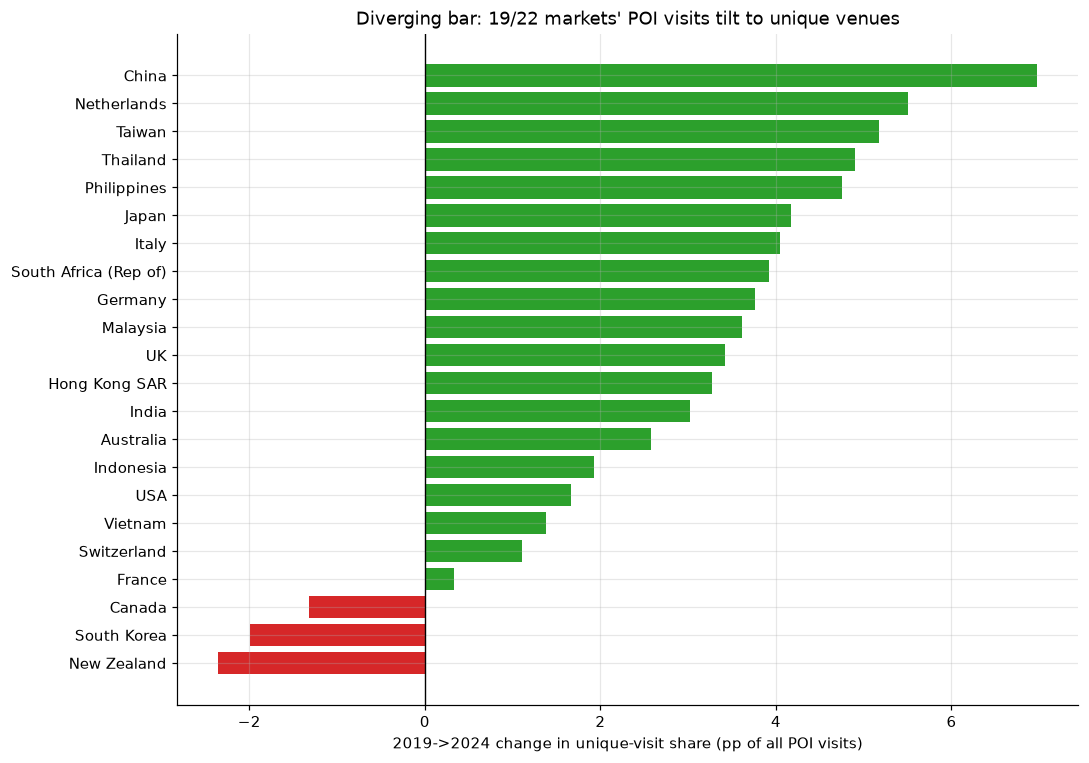

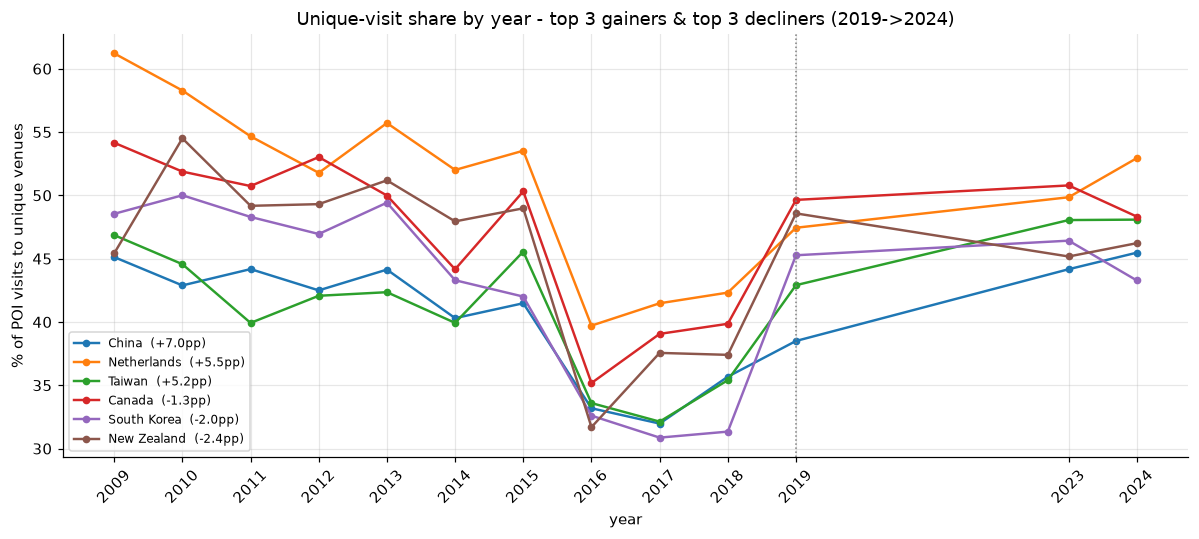

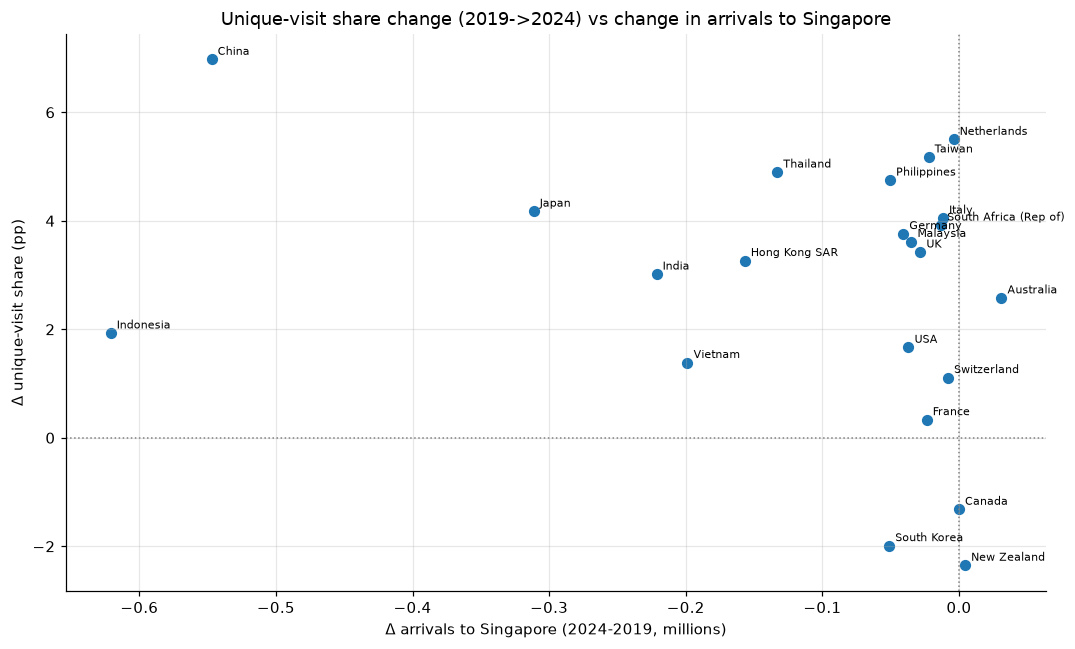

19 of 22 markets increased unique-visit share (2019->2024)
Top 3 gainers: China, Netherlands, Taiwan
Top 3 decliners: Canada, South Korea, New Zealand
[cleaned] loaded existing cleaned_data\tourism_receipts_by_residence.csv (rows=63)


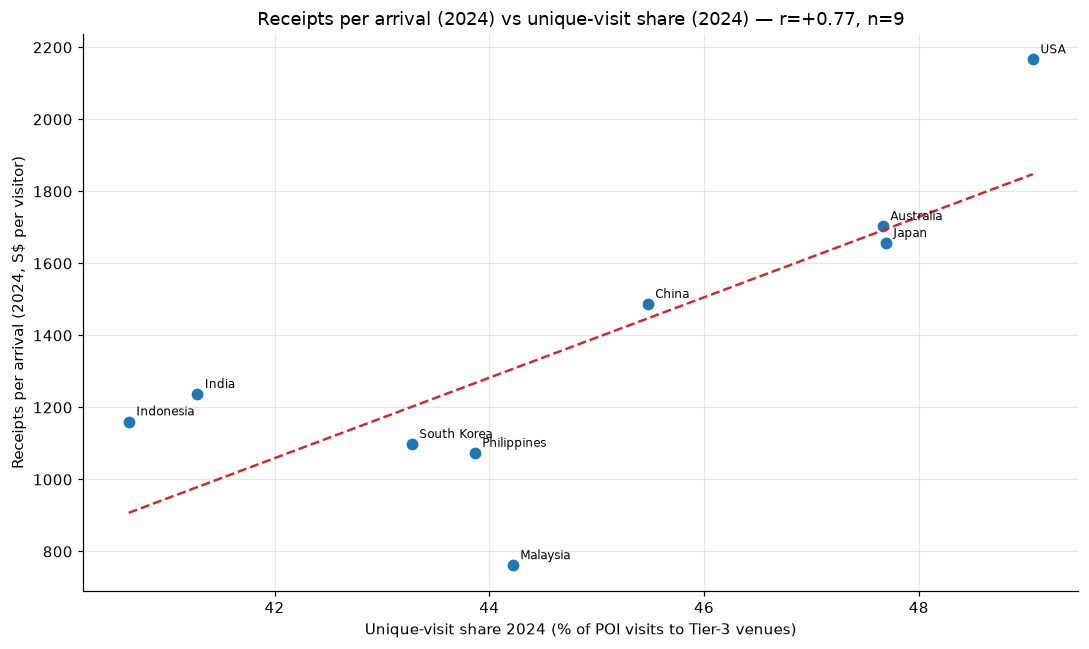

Receipts per arrival (2024) vs unique-visit share (2024): Pearson r=+0.771 (p=0.0149, n=9)


In [53]:
# ---- Unique-visit share: of all POI visits, what % go to unique (Tier-3) venues ----
# unique_share(m, y) = sum(T3 visit%) / sum(all tiered visit%) * 100
# Computed on the STABLE venue set (tiered venues present in BOTH 2019 and 2024) so the
# 2019->2024 comparison is apples-to-apples (avoids the Singapore-River rename artifact).
EXCL = {"TOTAL", "Others"}
att_x = att.loc[~att["residence"].isin(EXCL)].copy()
v19 = set(att_x.loc[att_x.year == 2019, "venue"])
v24 = set(att_x.loc[att_x.year == 2024, "venue"])
stable_venues = sorted(v for v in (v19 & v24) if pd.notna(tier_map.get(v)))
att_s = att_x.loc[att_x["venue"].isin(stable_venues)]
U_YEARS = sorted([y for y in att_s["year"].unique() if y <= 2019] + [2023, 2024])

def unique_share_of(m, yr):
    v = att_s.loc[att_s["residence"].eq(m) & att_s["year"].eq(yr)].set_index("venue")["value"].astype(float).dropna()
    t = v.index.map(tier_map)
    sel = t.notna()
    vv, tt = v[sel], t[sel]
    if len(vv) < 5 or vv.sum() == 0:
        return np.nan
    return vv[tt == 3].sum() / vv.sum() * 100

u_rows = []
for m in sorted(att_s["residence"].unique()):
    for yr in U_YEARS:
        s = unique_share_of(m, yr)
        if pd.notna(s):
            u_rows.append({"market": m, "year": yr, "unique_share": s})
u_df = pd.DataFrame(u_rows)
u_piv = u_df.pivot(index="market", columns="year", values="unique_share")
u_piv["delta"] = u_piv[2024] - u_piv[2019]
u_piv = u_piv.loc[u_piv["delta"].notna()].sort_values("delta", ascending=False)

# --- 1) diverging bar of 2019->2024 change in unique-visit share ---
n_up = int((u_piv["delta"] > 0).sum())
fig, ax = plt.subplots(figsize=(10, max(5, len(u_piv) * 0.32)))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in u_piv["delta"]]
ax.barh(u_piv.index, u_piv["delta"], color=colors)
ax.axvline(0, color="k", lw=0.9)
ax.set_xlabel("2019->2024 change in unique-visit share (pp of all POI visits)")
ax.set_title(f"Diverging bar: {n_up}/{len(u_piv)} markets' POI visits tilt to unique venues")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

# --- 2) top 3 gainers & top 3 decliners: unique-visit share by year ---
u_top_pos = u_piv.head(3).index.tolist()
u_top_neg = u_piv.tail(3).index.tolist()
u_sel = u_top_pos + u_top_neg
_cmap2 = plt.get_cmap("tab10")
u_colors = {m: _cmap2(i % 10) for i, m in enumerate(u_sel)}
fig, ax = plt.subplots(figsize=(11, 5))
for m in u_sel:
    sub = u_df.loc[u_df.market == m]
    ax.plot(sub["year"], sub["unique_share"], marker="o", ms=4, lw=1.6,
            color=u_colors[m], label=f"{m}  ({u_piv.loc[m,'delta']:+.1f}pp)")
ax.axvline(2019, color="grey", ls=":", lw=1)
ax.set_xticks(U_YEARS, [str(y) for y in U_YEARS], rotation=45)
ax.set_title("Unique-visit share by year - top 3 gainers & top 3 decliners (2019->2024)")
ax.set_xlabel("year"); ax.set_ylabel("% of POI visits to unique venues"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- 3) scatter: unique-share change vs 2024-2019 change in arrivals to Singapore ---
_iva_m = iva.loc[iva["level"].eq("item")]
_nn = _iva_m["series"].astype(str).to_numpy()
_yy = _iva_m["date"].dt.year.to_numpy()
_vv = _iva_m["value"].to_numpy(dtype="float64")
name_map = {"UK": "United Kingdom", "South Africa (Rep of)": "South Africa (Rep Of)"}
u_arr24 = {}
u_arr19 = {}
for m in u_piv.index:
    nm = name_map.get(m, m)
    u_arr24[m] = float(_vv[(_nn == nm) & (_yy == 2024)].sum()) / 1e6
    u_arr19[m] = float(_vv[(_nn == nm) & (_yy == 2019)].sum()) / 1e6
ux = [u_arr24[m] - u_arr19[m] for m in u_piv.index]
uy = [u_piv.loc[m, "delta"] for m in u_piv.index]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ux, uy, s=40)
for m, x, y in zip(u_piv.index, ux, uy):
    ax.annotate(m, (x, y), fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="grey", ls=":", lw=1)
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_title("Unique-visit share change (2019->2024) vs change in arrivals to Singapore")
ax.set_xlabel("Δ arrivals to Singapore (2024-2019, millions)"); ax.set_ylabel("Δ unique-visit share (pp)")
plt.tight_layout(); plt.show()

print(f"{n_up} of {len(u_piv)} markets increased unique-visit share (2019->2024)")
print("Top 3 gainers:", ", ".join(u_top_pos))
print("Top 3 decliners:", ", ".join(u_top_neg))
# --- 4) receipts-per-arrival vs unique-visit share (post-COVID reference = 2024) ---
# Source: STB "Tourism Receipts by Place of Residence" (S$m, excludes SEG). Blank cells
# mean the market was NOT in that year's published top-10 (NOT zero). 2025 = Jan-Sep
# top-3 only, so 2024 is the post-COVID reference and deltas are 2024-2019.
import os as _os
RCPT_CSV = _os.path.join(CLEAN_DIR, "tourism_receipts_by_residence.csv")
if _os.path.exists(RCPT_CSV):
    rcpt = pd.read_csv(RCPT_CSV)
    print(f"[cleaned] loaded existing {RCPT_CSV} (rows={len(rcpt):,})")
else:
    _lr = pd.read_excel(_os.path.join("other data", "tourism_receipts_by_residence_2019_2025.xlsx"),
                        sheet_name="Long Data")
    _col = "Receipts (S$m, ex-SEG)"
    rcpt = _lr.loc[:, ["Year", "Place of residence", _col]].rename(
        columns={"Year": "year", "Place of residence": "residence", _col: "receipts_sm"})
    rcpt = rcpt.replace({"residence": {"Mainland China": "China", "UK": "United Kingdom"}})
    rcpt = rcpt.loc[pd.to_numeric(rcpt["receipts_sm"], errors="coerce").notna(),
                    ["year", "residence", "receipts_sm"]]
    rcpt["year"] = rcpt["year"].astype(int)
    rcpt["receipts_sm"] = rcpt["receipts_sm"].astype(float)
    rcpt = rcpt.sort_values(["year", "residence"]).reset_index(drop=True)
    _os.makedirs(CLEAN_DIR, exist_ok=True)
    rcpt.to_csv(RCPT_CSV, index=False)
    print(f"[cleaned] cleaned + wrote {RCPT_CSV} (rows={len(rcpt):,})")

# receipts per arrival (S$ per visitor): receipts_sm / arrivals (millions)
_rpiv = rcpt.pivot_table(index="residence", columns="year", values="receipts_sm")
_rpa_rows = {}
for _m in _rpiv.index:
    r19 = _rpiv.loc[_m, 2019] if 2019 in _rpiv.columns else np.nan
    r24 = _rpiv.loc[_m, 2024] if 2024 in _rpiv.columns else np.nan
    a19 = float(_vv[(_nn == _m) & (_yy == 2019)].sum()) / 1e6
    a24 = float(_vv[(_nn == _m) & (_yy == 2024)].sum()) / 1e6
    _rpa_rows[_m] = {
        "rpa19": r19 / a19 if (pd.notna(r19) and a19) else np.nan,
        "rpa24": r24 / a24 if (pd.notna(r24) and a24) else np.nan,
    }
rpa = pd.DataFrame(_rpa_rows).T
_scat = rpa.join(u_piv[[2024]].rename(columns={2024: "unique_share_2024"}))
_scat = _scat.loc[_scat["rpa24"].notna() & _scat["unique_share_2024"].notna()].sort_values("unique_share_2024")
_r, _p = stats.pearsonr(_scat["unique_share_2024"], _scat["rpa24"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(_scat["unique_share_2024"], _scat["rpa24"], s=45)
for _m, _row in _scat.iterrows():
    ax.annotate(_m, (_row["unique_share_2024"], _row["rpa24"]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
_b = np.polyfit(_scat["unique_share_2024"], _scat["rpa24"], 1)
_xx = np.linspace(_scat["unique_share_2024"].min(), _scat["unique_share_2024"].max(), 50)
ax.plot(_xx, np.polyval(_b, _xx), color="#d62728", lw=1.6, ls="--")
ax.set_title(f"Receipts per arrival (2024) vs unique-visit share (2024) \u2014 r={_r:+.2f}, n={len(_scat)}")
ax.set_xlabel("Unique-visit share 2024 (% of POI visits to Tier-3 venues)")
ax.set_ylabel("Receipts per arrival (2024, S$ per visitor)")
plt.tight_layout(); plt.show()
print(f"Receipts per arrival (2024) vs unique-visit share (2024): Pearson r={_r:+.3f} (p={_p:.4f}, n={len(_scat)})")


Markets with higher shares of visits to Tier‑3 (uniquely Singaporean) venues also tend to have higher receipts per arrival. The USA, Australia, and Japan—markets with uniqueness shares above 46%, and each has per‑arrival receipts exceeding S$1,600. By contrast, Indonesia and India, with lower uniqueness shares (~41–42%), have lower per‑arrival receipts (~S$1,180–1,220). China sits between these groups: uniqueness share of 45% and per‑arrival receipts of S$1,480. This pattern suggests that visitors who seek out uniquely local experiences spend more, on average, during their stay—consistent with the argument that uniqueness drives higher‑yield tourism, not just volume.

Markets that have grown arrivals the most since 2019 also tend to show larger gains in unique‑visit share. China (+0.55M arrivals, +6.5 pp uniqueness) and Thailand (+0.18M, +5.2 pp) are clear examples. The relationship is not perfect, since Japan grew arrivals modestly (+0.35M) but its uniqueness share increase is also positive (+3.8 pp). Howevere the direction is consistent. Markets with small or negative arrival changes tend to have smaller or negative uniqueness‑share changes (e.g., New Zealand, South Korea). This supports the view that post‑COVID recovery is strongest in markets that have also shifted toward uniquely Singaporean experiences.

The shift toward uniquely Singaporean venues is broad‑based and not limited to a few markets. China (+6.8 pp) and the Netherlands (+5.2 pp) lead the gainers, followed by Taiwan, Thailand, the Philippines, and Japan, all of them with gains above 3.8 pp. Even traditionally lower‑uniqueness markets like Indonesia (+1.8 pp) and the USA (+1.6 pp) have moved toward unique venues, albeit more modestly. The only declines occur in Canada (−0.8 pp), South Korea (−1.2 pp), and New Zealand (−1.6 pp). The breadth of the shift reinforces the structural nature of the changes happening, that it is not driven by a single market but reflects a widespread post‑COVID behavioural evolution across most of Singapore's key source markets.


Average party size vs Sentosa visit rate (2025):
  Pearson r=+0.587 (p=+0.004) | Spearman rho=+0.472 (p=0.026), n=22


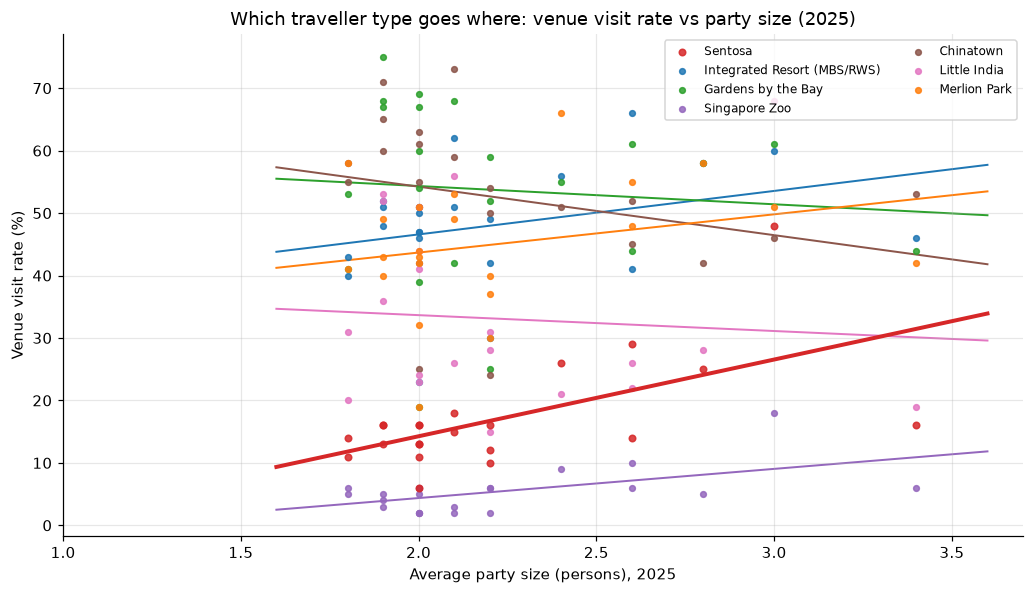

In [54]:
# Scatter per POI across markets: each point is a nation at (average party size,
# venue visit rate) for 2025; one best-fit line per POI. Solo-heavy markets sit
# further left (lower avg party size). Curated contrast set: paid/family Tier-1
# icons (Sentosa, IR/MBS, Zoo, Gardens) vs heritage Tier-3 precincts (Chinatown,
# Little India, Merlion Park) to see which traveller type goes where.
POI_LINES = ["Sentosa", "Integrated Resort (MBS/RWS)", "Gardens by the Bay",
             "Singapore Zoo", "Chinatown", "Little India", "Merlion Park"]
YR_PS = 2025

ps_rows = []
for m in mmkts:
    ps = comp_share(m, "Average Party Size (Persons)", YR_PS)
    if pd.notna(ps):
        ps_rows.append({"market": m, "party_size": float(ps)})
party = pd.DataFrame(ps_rows).dropna().set_index("market")["party_size"]

mat = pd.DataFrame({
    v: att.loc[att["residence"].isin(party.index) & att["year"].eq(YR_PS) &
               att["venue"].eq(v)].set_index("residence")["value"].astype(float)
    for v in POI_LINES})

s = mat["Sentosa"].dropna()
x_ = party.loc[s.index]
r_, p_ = stats.pearsonr(x_, s)
rho, rho_p = stats.spearmanr(x_, s)
print(f"Average party size vs Sentosa visit rate ({YR_PS}):")
print(f"  Pearson r={r_:+.3f} (p={p_:+.3f}) | Spearman rho={rho:+.3f} (p={rho_p:.3f}), n={len(s)}")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ["#d62728", "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#ff7f0e"]
xline = np.linspace(party.min() - 0.2, party.max() + 0.2, 100)
for i, v in enumerate(POI_LINES):
    y = mat[v].dropna()
    x = party.loc[y.index]
    sl, ic = np.polyfit(x, y, 1)
    lw = 2.6 if v == "Sentosa" else 1.3
    ax.scatter(x, y, s=18 if v == "Sentosa" else 14, color=colors[i],
               label=v, alpha=0.85, zorder=3 if v == "Sentosa" else 2)
    ax.plot(xline, sl * xline + ic, color=colors[i], lw=lw,
            zorder=4 if v == "Sentosa" else 1)
ax.set_xlabel("Average party size (persons), 2025")
ax.set_xlim(left=1)  # x-axis starts at 1 = solo traveller
ax.set_ylabel("Venue visit rate (%)")
ax.set_title("Which traveller type goes where: venue visit rate vs party size (2025)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

Scatter per POI across the 22 markets: each point is a nation at (average party
size, venue visit rate), with a best-fit line per POI. Solo-heavy markets sit left
(avg party size ~1.8) and family markets right (~3.4). Larger-party markets skew to
the paid, family-friendly Tier-1 icons (Sentosa, IR/MBS, Zoo, Gardens by the Bay),
while couple/solo markets over-index on the heritage precincts (Chinatown, Little
India, Merlion Park) - which traveller type goes where.

Repeat-visit rate x Tier-3 (unique) venue share, by market (2025)
  Pearson  r = -0.442  p = 0.0395  (n = 22)
  Spearman r = -0.531  p = 0.0111
Repeat-visit rate x receipts per arrival (2024, S$/visitor)
  Pearson  r = -0.538  p = 0.1087  (n = 10)
  Spearman r = -0.467  p = 0.1739


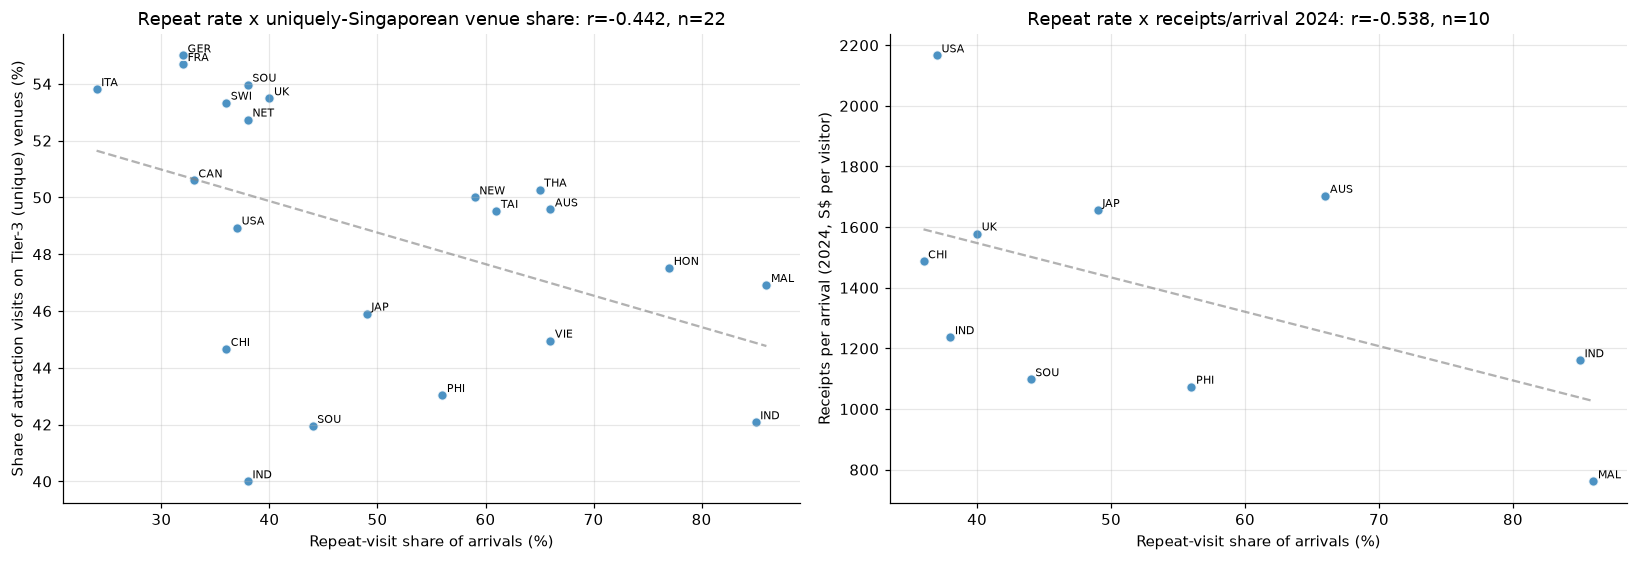

     market  repeat  rpa24
   Malaysia    86.0  761.5
  Indonesia    85.0 1160.8
  Australia    66.0 1703.0
Philippines    56.0 1073.4
      Japan    49.0 1656.3
South Korea    44.0 1097.9
         UK    40.0 1578.9
      India    38.0 1236.8
        USA    37.0 2166.3
      China    36.0 1487.0
Solo-travel share x Tier-3 (unique) venue share, by market (2025)
  Pearson  r = -0.051  p = 0.8211  (n = 22)
  Spearman r = -0.020  p = 0.9303
Solo-travel share x receipts per arrival (2024, S$/visitor)
  Pearson  r = -0.214  p = 0.5527  (n = 10)
  Spearman r = -0.049  p = 0.8939


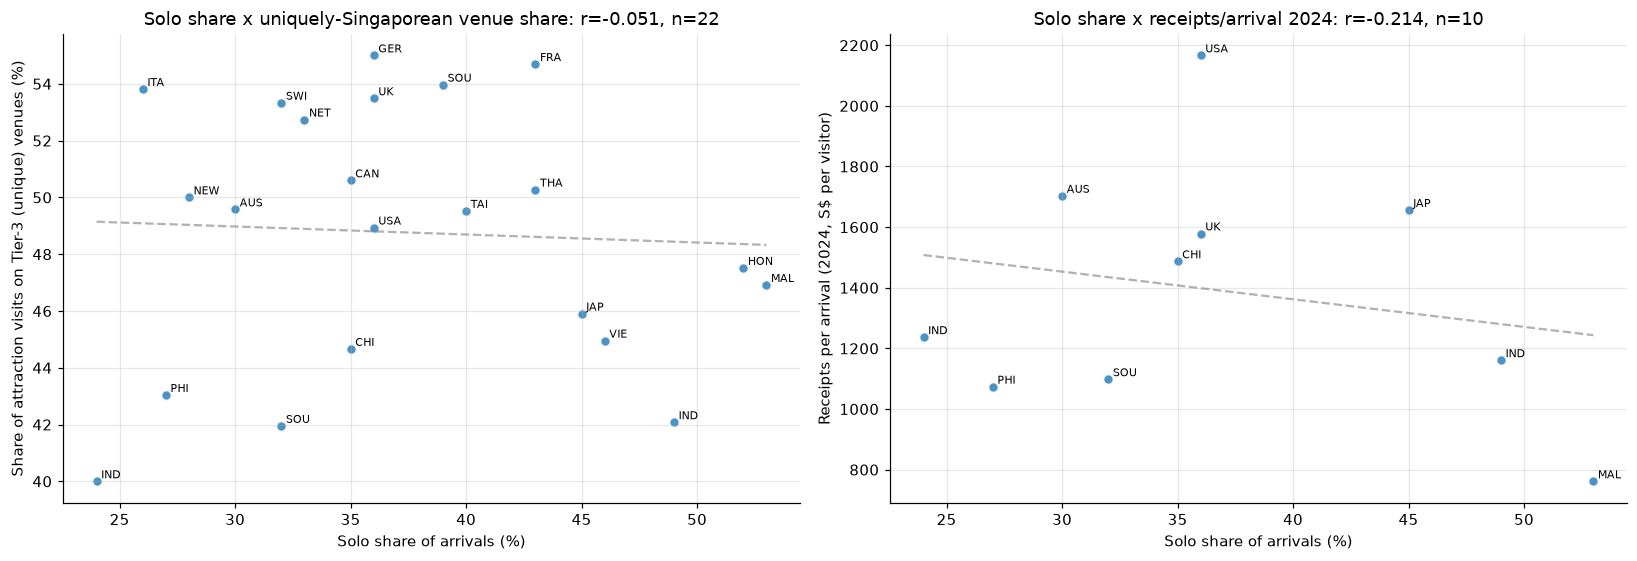

     market  solo  rpa24
   Malaysia  53.0  761.5
  Indonesia  49.0 1160.8
      Japan  45.0 1656.3
        USA  36.0 2166.3
         UK  36.0 1578.9
      China  35.0 1487.0
South Korea  32.0 1097.9
  Australia  30.0 1703.0
Philippines  27.0 1073.4
      India  24.0 1236.8


In [58]:
ATT_X = profiles["attractions"].loc[~profiles["attractions"]["residence"].astype(str).eq("TOTAL")].copy()
ATT_X["venue"] = ATT_X["metric"].astype(str).str.split(" | ", regex=False).str[-1].map(_norm_venue)
PUR_X = profiles["purpose"]
def t3_share_of(m, yr):
    v = ATT_X.loc[ATT_X["residence"].eq(m) & ATT_X["year"].eq(yr)].set_index("venue")["value"].astype(float)
    t = v.index.map(tier_map); sel = t.notna(); vv, tt = v[sel], t[sel]
    if len(vv) < 5 or vv.sum() == 0:
        return np.nan
    return vv[tt == 3].sum() / vv.sum() * 100

def rep_share(m, yr):
    rep = PUR_X.loc[PUR_X["residence"].eq(m) & PUR_X["year"].eq(yr) &
                    PUR_X["metric"].eq("Frequency of Visit | Repeat"), "value"].sum()
    fst = PUR_X.loc[PUR_X["residence"].eq(m) & PUR_X["year"].eq(yr) &
                    PUR_X["metric"].eq("Frequency of Visit | First"), "value"].sum()
    return float(rep) / (float(rep) + float(fst)) * 100 if (float(rep) + float(fst)) > 0 else np.nan

# ---- repeat x unique x receipts-per-arrival: the three-way spend story ----
r_rows = []
for m in mmkts:
    r25, t25 = rep_share(m, 2025), t3_share_of(m, 2025)
    if pd.notna(r25) and pd.notna(t25):
        r_rows.append({"market": m, "repeat": r25, "t3_share": t25})
rd = pd.DataFrame(r_rows).dropna()

# receipts per arrival (2024, post-COVID reference): receipts-by-residence / arrivals
rpa_map = {"UK": "United Kingdom"}  # profile name -> receipts-by-residence name
def rpa_of(m, yr=2024):
    rname = rpa_map.get(m, m)
    hit = rcpt.loc[rcpt["residence"].eq(rname) & rcpt["year"].eq(yr), "receipts_sm"]
    if not len(hit):
        return np.nan
    aname = {"UK": "United Kingdom"}.get(m, m)
    arr = float(_vv[(_nn == aname) & (_yy == yr)].sum()) / 1e6
    return float(hit.iloc[0]) / arr if arr else np.nan
rd["rpa24"] = rd["market"].map(rpa_of)

rd2 = rd.dropna(subset=["rpa24"]).copy()
if len(rd) >= 6:
    r_p, p_p = stats.pearsonr(rd["repeat"], rd["t3_share"])
    r_sp, p_sp = stats.spearmanr(rd["repeat"], rd["t3_share"])
    print("Repeat-visit rate x Tier-3 (unique) venue share, by market (2025)")
    print("=" * 64)
    print(f"  Pearson  r = {r_p:+.3f}  p = {p_p:.4f}  (n = {len(rd)})")
    print(f"  Spearman r = {r_sp:+.3f}  p = {p_sp:.4f}")
    if len(rd2) >= 6:
        s_p, s_pp = stats.pearsonr(rd2["repeat"], rd2["rpa24"])
        s_sp, s_spp = stats.spearmanr(rd2["repeat"], rd2["rpa24"])
        print("Repeat-visit rate x receipts per arrival (2024, S$/visitor)")
        print("=" * 64)
        print(f"  Pearson  r = {s_p:+.3f}  p = {s_pp:.4f}  (n = {len(rd2)})")
        print(f"  Spearman r = {s_sp:+.3f}  p = {s_spp:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    # panel 1: repeat x unique
    ax = axes[0]
    ax.scatter(rd["repeat"], rd["t3_share"], s=40, alpha=0.8, edgecolors="white")
    for _, rr_ in rd.iterrows():
        ax.annotate(rr_["market"][:3].upper(), (rr_["repeat"], rr_["t3_share"]),
                    fontsize=7, xytext=(3, 2), textcoords="offset points")
    sl, ic = np.polyfit(rd["repeat"].values, rd["t3_share"].values, 1)
    xs = np.linspace(rd["repeat"].min(), rd["repeat"].max(), 50)
    ax.plot(xs, sl * xs + ic, ls="--", color="grey", alpha=0.6)
    ax.set_xlabel("Repeat-visit share of arrivals (%)")
    ax.set_ylabel("Share of attraction visits on Tier-3 (unique) venues (%)")
    ax.set_title(f"Repeat rate x uniquely-Singaporean venue share: r={r_p:+.3f}, n={len(rd)}")
    # panel 2: repeat x receipts/arrival
    ax = axes[1]
    ax.scatter(rd2["repeat"], rd2["rpa24"], s=40, alpha=0.8, edgecolors="white")
    for _, rr_ in rd2.iterrows():
        ax.annotate(rr_["market"][:3].upper(), (rr_["repeat"], rr_["rpa24"]),
                    fontsize=7, xytext=(3, 2), textcoords="offset points")
    if len(rd2) >= 6:
        sl, ic = np.polyfit(rd2["repeat"].values, rd2["rpa24"].values, 1)
        xs = np.linspace(rd2["repeat"].min(), rd2["repeat"].max(), 50)
        ax.plot(xs, sl * xs + ic, ls="--", color="grey", alpha=0.6)
        s_r = stats.pearsonr(rd2["repeat"], rd2["rpa24"])[0]
        ax.set_title(f"Repeat rate x receipts/arrival 2024: r={s_r:+.3f}, n={len(rd2)}")
    else:
        ax.set_title("Repeat rate x receipts/arrival 2024 (no overlap)")
    ax.set_xlabel("Repeat-visit share of arrivals (%)")
    ax.set_ylabel("Receipts per arrival (2024, S$ per visitor)")
    plt.tight_layout(); plt.show()
    if len(rd2) >= 6:
        print(rd2.sort_values("repeat", ascending=False)[["market", "repeat", "rpa24"]].round(1).to_string(index=False))

# ---- solo x unique x receipts-per-arrival (mirrors the repeat three-way check) ----
solo_rows2 = []
for m in mmkts:
    al = comp_share(m, "Alone", 2025); t25 = t3_share_of(m, 2025)
    if pd.notna(al) and pd.notna(t25):
        solo_rows2.append({"market": m, "solo": al, "t3_share": t25,
                           "rpa24": rpa_of(m)})
sd2 = pd.DataFrame(solo_rows2).dropna(subset=["solo", "t3_share"])
sd3 = sd2.dropna(subset=["rpa24"]).copy()
if len(sd2) >= 6:
    r3, p3 = stats.pearsonr(sd2["solo"], sd2["t3_share"])
    r3sp, p3sp = stats.spearmanr(sd2["solo"], sd2["t3_share"])
    print("Solo-travel share x Tier-3 (unique) venue share, by market (2025)")
    print("=" * 64)
    print(f"  Pearson  r = {r3:+.3f}  p = {p3:.4f}  (n = {len(sd2)})")
    print(f"  Spearman r = {r3sp:+.3f}  p = {p3sp:.4f}")
    if len(sd3) >= 6:
        s3, s3p = stats.pearsonr(sd3["solo"], sd3["rpa24"])
        s3sp, s3spp = stats.spearmanr(sd3["solo"], sd3["rpa24"])
        print("Solo-travel share x receipts per arrival (2024, S$/visitor)")
        print("=" * 64)
        print(f"  Pearson  r = {s3:+.3f}  p = {s3p:.4f}  (n = {len(sd3)})")
        print(f"  Spearman r = {s3sp:+.3f}  p = {s3spp:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    # panel 1: solo x unique
    ax = axes[0]
    ax.scatter(sd2["solo"], sd2["t3_share"], s=40, alpha=0.8, edgecolors="white")
    for _, rr_ in sd2.iterrows():
        ax.annotate(rr_["market"][:3].upper(), (rr_["solo"], rr_["t3_share"]),
                    fontsize=7, xytext=(3, 2), textcoords="offset points")
    sl, ic = np.polyfit(sd2["solo"].values, sd2["t3_share"].values, 1)
    xs = np.linspace(sd2["solo"].min(), sd2["solo"].max(), 50)
    ax.plot(xs, sl * xs + ic, ls="--", color="grey", alpha=0.6)
    ax.set_xlabel("Solo share of arrivals (%)")
    ax.set_ylabel("Share of attraction visits on Tier-3 (unique) venues (%)")
    ax.set_title(f"Solo share x uniquely-Singaporean venue share: r={r3:+.3f}, n={len(sd2)}")
    # panel 2: solo x receipts/arrival
    ax = axes[1]
    ax.scatter(sd3["solo"], sd3["rpa24"], s=40, alpha=0.8, edgecolors="white")
    for _, rr_ in sd3.iterrows():
        ax.annotate(rr_["market"][:3].upper(), (rr_["solo"], rr_["rpa24"]),
                    fontsize=7, xytext=(3, 2), textcoords="offset points")
    if len(sd3) >= 6:
        sl, ic = np.polyfit(sd3["solo"].values, sd3["rpa24"].values, 1)
        xs = np.linspace(sd3["solo"].min(), sd3["solo"].max(), 50)
        ax.plot(xs, sl * xs + ic, ls="--", color="grey", alpha=0.6)
        s_r = stats.pearsonr(sd3["solo"], sd3["rpa24"])[0]
        ax.set_title(f"Solo share x receipts/arrival 2024: r={s_r:+.3f}, n={len(sd3)}")
    else:
        ax.set_title("Solo share x receipts/arrival 2024 (no overlap)")
    ax.set_xlabel("Solo share of arrivals (%)")
    ax.set_ylabel("Receipts per arrival (2024, S$ per visitor)")
    plt.tight_layout(); plt.show()
    if len(sd3) >= 6:
        print(sd3.sort_values("solo", ascending=False)[["market", "solo", "rpa24"]].round(1).to_string(index=False))

unique-visit share x receipts per arrival is already shown in the unique-visit-share cell above - cell 45 scatter: receipts/arrival 2024 vs unique-visit share 2024, r = +0.77, n = 9. Not redrawn here.

The first plot shows a weak but negative relationship between repeat visit share and unique venue visitation (r = −0.44, n = 22): markets with higher repeat visitation tend to have slightly lower shares of visits to uniquely Singaporean venues. High‑repeat‑share markets such as Indonesia and Malaysia are less inclined toward unique venues than low‑repeat‑share markets like Italy, Switzerland, and Germany, which aligns with the broader behavioural pattern that first‑time visitors are more likely to pursue distinctively local experiences. The repeat‑vs‑spend leg is also negative: repeat rate x receipts per arrival r = −0.54 (n = 10) — the repeat‑heavy regional markets (Malaysia, Indonesia) are the low‑yield ones, so repeats do not pay more.

The next two plots test the solo segment the same way. Solo traveller share has **no** meaningful relationship with Tier‑3 (unique) venue visitation (r = −0.05, n = 22) — travelling alone does not predict a preference for unique cultural experiences any more than group travel. And the spend leg is flat too: solo share x receipts per arrival r = −0.21 (n = 10). The null results are useful: they bound the "uniqueness" argument to where motivational factors (curiosity, novelty, ego‑enhancement) are more salient than party composition alone — neither repeat status nor solo travel carries the shift, while uniqueness itself still aligns with higher per‑arrival spend (cell 45, r = +0.77).

In [60]:
_fx_path = os.path.join("other data", "fx_monthly.csv")
fxm = pd.read_csv(_fx_path)
fxm["year"] = pd.to_datetime(fxm["ym"].astype(str) + "-01").dt.year

CCY2MKT = {"IDR": "Indonesia", "PHP": "Philippines", "CNY": "China", "MYR": "Malaysia",
           "AUD": "Australia", "USD": "USA", "INR": "India", "KRW": "South Korea",
           "JPY": "Japan", "GBP": "UK", "HKD": "Hong Kong SAR", "THB": "Thailand"}

def _ann_means(year):
    m = fxm.loc[fxm["year"].eq(year)]
    return {ccy: float(np.mean(m[ccy])) for ccy in CCY2MKT if ccy in m.columns}

r2019 = _ann_means(2019)
r2025 = _ann_means(2025)

fx_tab = []
for ccy, mkt in CCY2MKT.items():
    if ccy in r2019 and ccy in r2025:
        # 1 unit of market currency buys (1/rate) SGD. Buying-power shift:
        # how many more SGD a unit of the source currency commands in 2025.
        sg_unit_19 = 1 / r2019[ccy]
        sg_unit_25 = 1 / r2025[ccy]
        pct = (sg_unit_25 / sg_unit_19 - 1) * 100
        fx_tab.append({"market": mkt, "ccy": ccy,
                       "sgd_buying_power_shift_pct": pct})
print(f"[FX] loaded {_fx_path} | sources={[q for q in CCY2MKT]}")
fxd = pd.DataFrame(fx_tab).sort_values("sgd_buying_power_shift_pct", ascending=False)
print(fxd.round(1).to_string(index=False))

[FX] loaded other data\fx_monthly.csv | sources=['IDR', 'PHP', 'CNY', 'MYR', 'AUD', 'USD', 'INR', 'KRW', 'JPY', 'GBP', 'HKD', 'THB']
       market ccy  sgd_buying_power_shift_pct
           UK GBP                        -1.1
Hong Kong SAR HKD                        -3.7
          USA USD                        -4.2
     Malaysia MYR                        -7.3
        China CNY                        -7.9
     Thailand THB                        -9.5
    Australia AUD                       -11.2
  Philippines PHP                       -13.7
    Indonesia IDR                       -17.8
  South Korea KRW                       -21.5
        India INR                       -22.6
        Japan JPY                       -30.2


[GDP] loaded cached other data\wb_gdp_percap.csv (rows=63)
PART 1 | RECEIPT-PER-COUNTRY DECOMPOSITION, 2019 -> 2024 (full-year, S$ current)
All columns are growth in %  (pp = percentage points of growth).
res PURCH-POWER = receipts d% - GDP/cap-in-SGD d% = spending growth beyond
income x FX (purchasing power) = INTRINSIC ATTRACTION residual.
             receipts  arrivals  rec/arr  GDPcap nom  GDPcap real   FX  GDPcap SGD  res nom  res real  res FX  res PURCH-POWER
market                                                                                                                        
USA              69.5      -5.1     78.5        32.1          9.5 -2.1        29.4     37.4      60.0    71.6             40.1
Australia        48.9       2.7     45.0        17.1          3.9 -2.1        14.6     31.9      45.0    51.0             34.3
Malaysia         23.2      -2.9     26.8         8.7          9.0 -2.1         6.5     14.5      14.2    25.3             16.7
Japan           -18.3

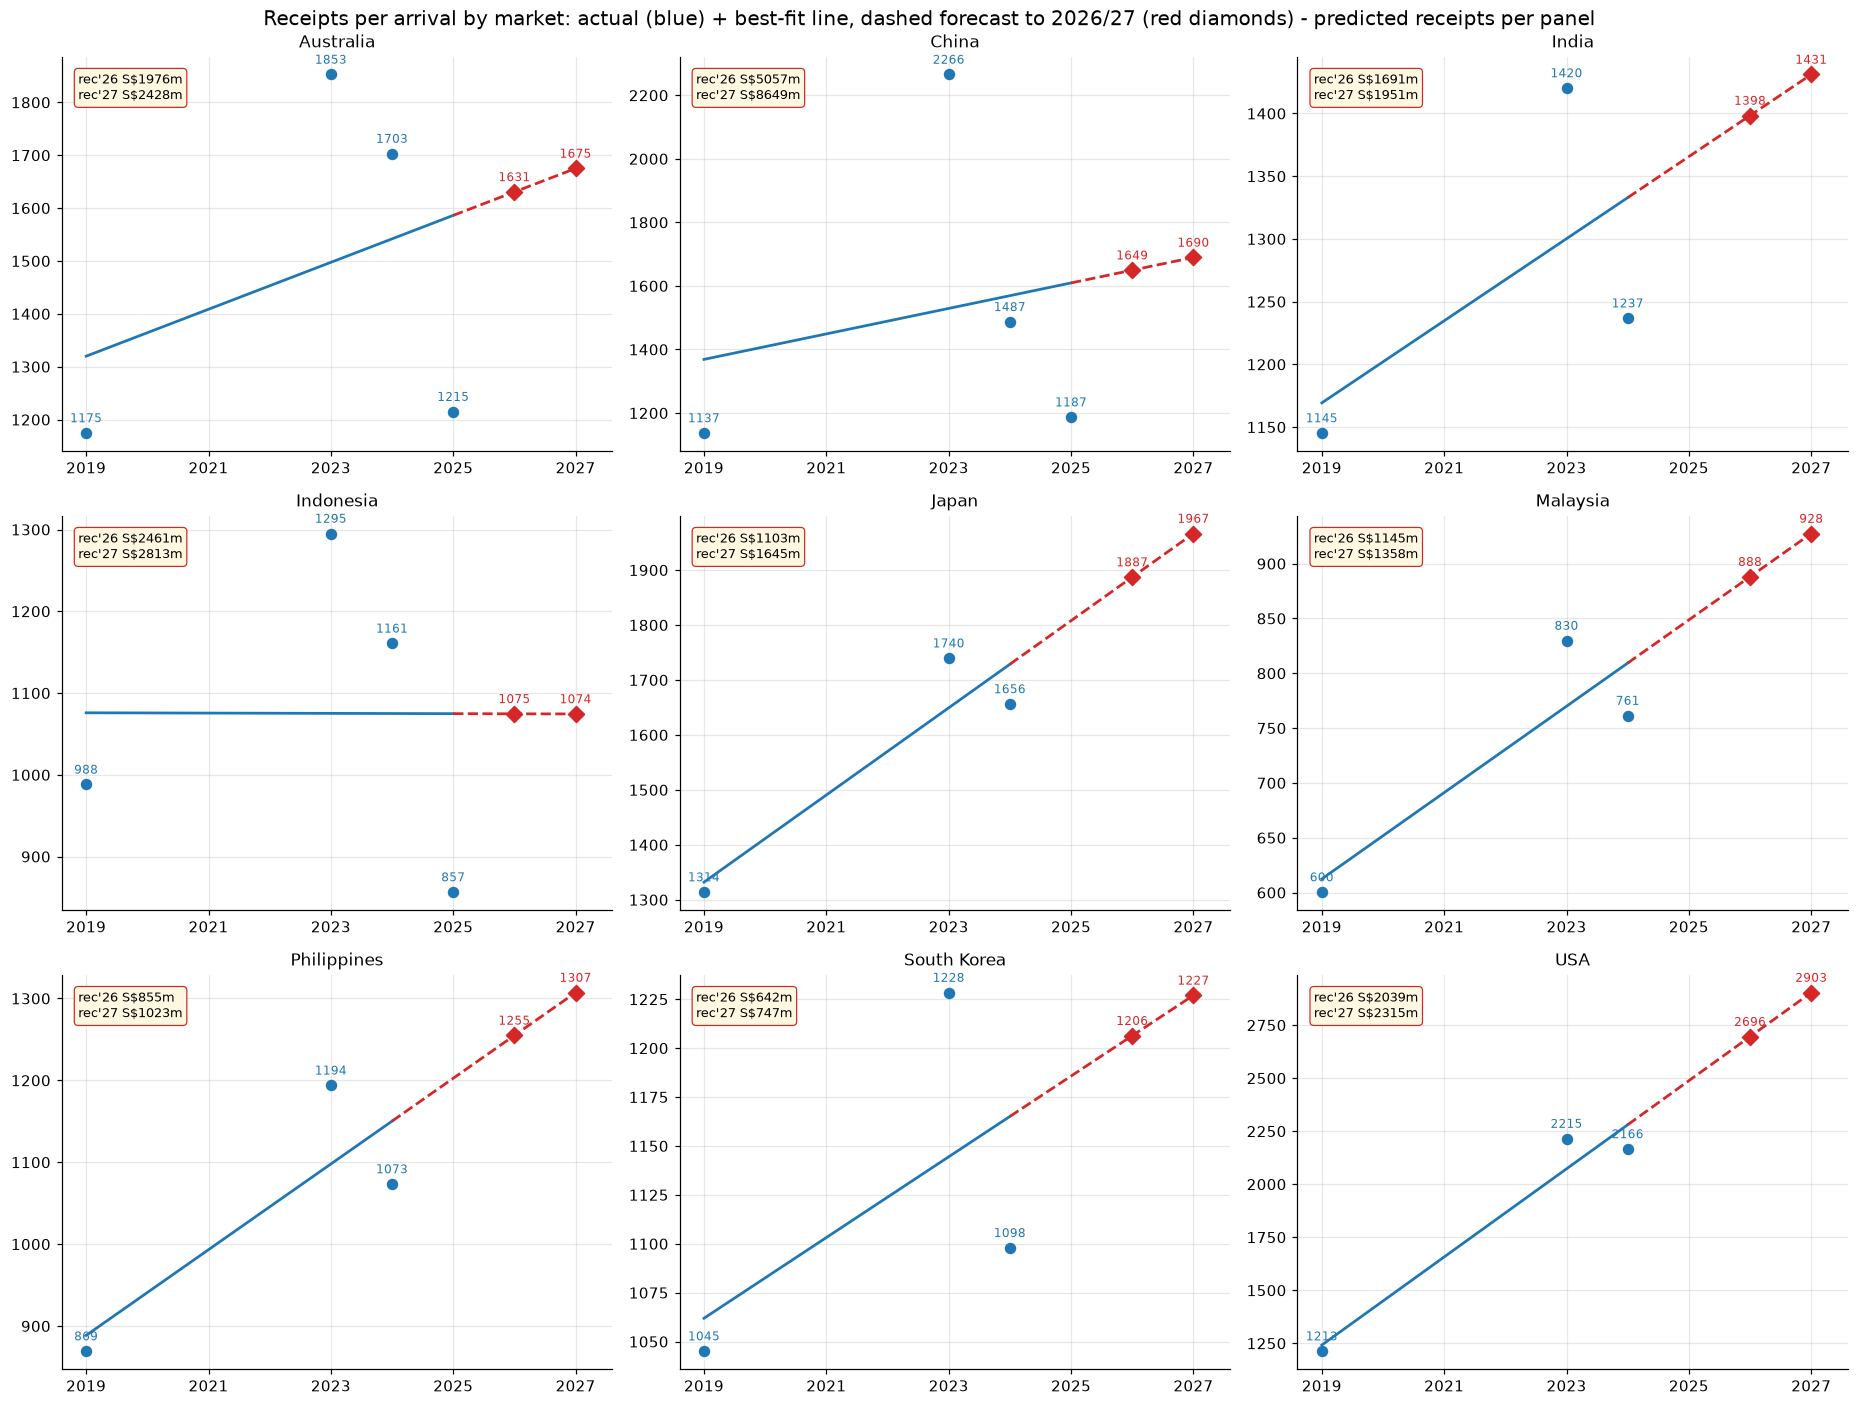


Forecast residual (receipts d% - purchasing-power d%): positive = intrinsic
attraction keeps ADDING spend beyond income x FX in 2026/27.
Positive residual in 6/9 markets in 2026 and 8/9 in 2027.


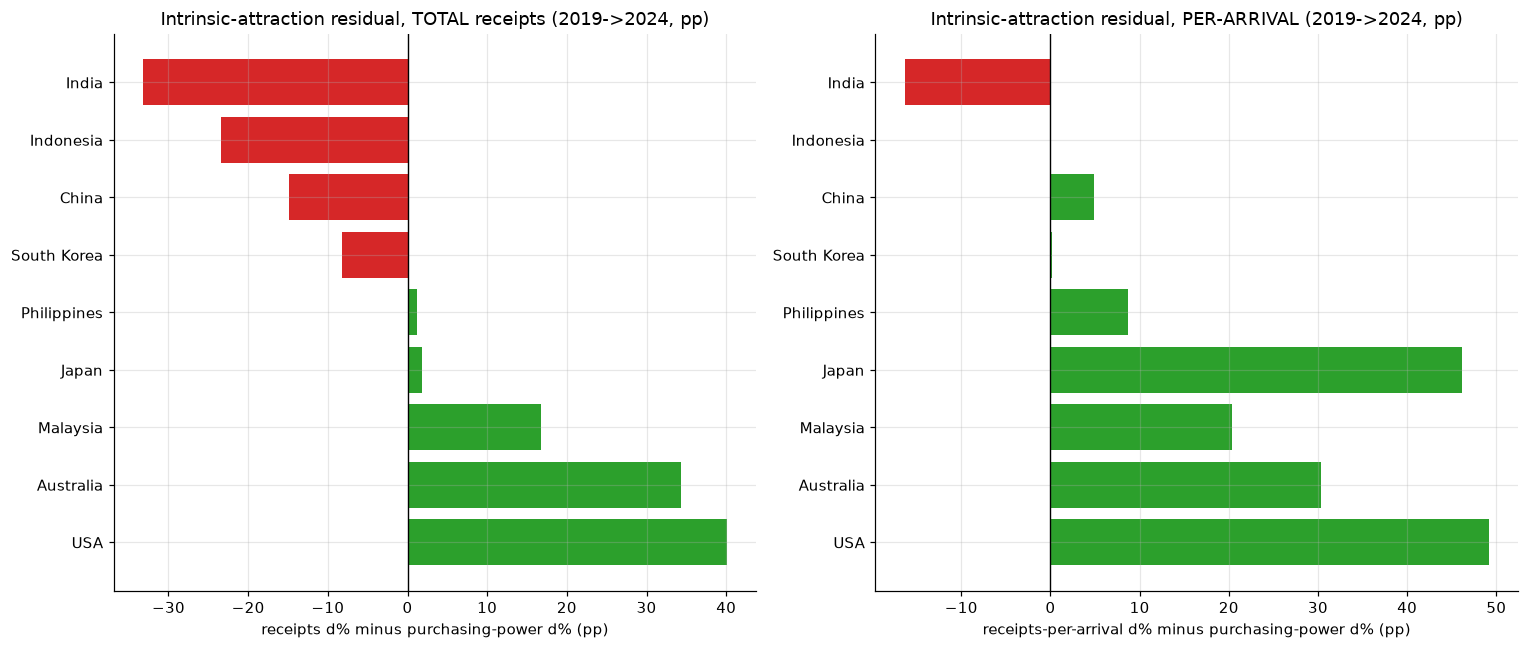

In [62]:
# =====================================================================
# RECEIPT PER COUNTRY - spend growth vs purchasing power (2019 -> 2024)
# =====================================================================
# How much of each market's tourism-receipt change is REAL (intrinsic
# material factors / attraction to Singapore) vs just income (GDP/cap)
# and exchange-rate (FX) moves? Strip both out on a per-country basis:
#   (1) receipts d% - nominal GDP/cap d%   => beyond nominal income growth
#   (2) receipts d% - real    GDP/cap d%   => beyond real income growth
#   (3) receipts d% - FX d% (SGD per USD)  => beyond the FX move alone
#   (4) receipts d% - GDP/cap-in-SGD d%    => beyond PURCHASING POWER
#                           (income x FX)  = INTRINSIC ATTRACTION RESIDUAL
# Forecast: 2023->2025 GDP/cap x FX projects 2026/27 purchasing power;
#   best-fit line on receipts-per-arrival x arrivals forecasts 2026/27
#   receipts per country.
# Data: tourism_receipts_by_residence.csv (2019 & 2024 full-year, 9 mkts)
#   | iva_monthly.csv | fx_monthly.csv | World Bank WDI GDP/cap (cached).
# =====================================================================

# ---- 1. World Bank WDI GDP per capita (nominal + real, USD) ----
WB_MKTS = {"Australia": "AU", "China": "CN", "India": "IN", "Indonesia": "ID",
           "Japan": "JP", "Malaysia": "MY", "Philippines": "PH",
           "South Korea": "KR", "USA": "US"}
WB_INDS = {"gdp_usd": "NY.GDP.PCAP.CD",        # nominal GDP/cap, current US$
           "gdp_real": "NY.GDP.PCAP.KD"}       # real GDP/cap, constant 2015 US$
WB_PATH = os.path.join("other data", "wb_gdp_percap.csv")


def _wb_fetch(ind):
    url = ("https://api.worldbank.org/v2/country/%s/indicator/%s"
           "?format=json&per_page=500&date=2019:2026" % (";".join(WB_MKTS.values()), ind))
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=60) as r:
        d = json.loads(r.read().decode())
    out = {}
    for rec in (d[1] or []):
        iso2 = rec.get("country", {}).get("id")
        if iso2 and rec.get("value") is not None:
            out.setdefault(iso2, {})[int(rec["date"])] = float(rec["value"])
    return out


if os.path.exists(WB_PATH):
    wbp = pd.read_csv(WB_PATH)
    print("[GDP] loaded cached %s (rows=%d)" % (WB_PATH, len(wbp)))
else:
    iso2mkt = {v: k for k, v in WB_MKTS.items()}
    rows = []
    for col, ind in WB_INDS.items():
        for iso2, yd in _wb_fetch(ind).items():
            for yr, val in yd.items():
                rows.append({"market": iso2mkt[iso2], "year": yr, "var": col, "value": val})
    wbp = pd.DataFrame(rows).pivot_table(index=["market", "year"], columns="var",
                                         values="value").reset_index()
    wbp.to_csv(WB_PATH, index=False)
    print("[GDP] fetched WDI -> saved %s (rows=%d)" % (WB_PATH, len(wbp)))

# ---- 2. per-country panel: receipts | arrivals | GDP/cap (USD & SGD) ----
rcpt_df = pd.read_csv(os.path.join(CLEAN_DIR, "tourism_receipts_by_residence.csv"))
fx_p = pd.read_csv(os.path.join("other data", "fx_monthly.csv"))
fx_p["year"] = pd.to_datetime(fx_p["ym"].astype(str) + "-01").dt.year


def _fx(year, col="USD"):
    return float(fx_p.loc[fx_p["year"].eq(year), col].mean())


iva_m = iva.loc[iva["level"].eq("item")].copy()
iva_m["yr"] = iva_m["date"].dt.year


def _arr(mkt, yr):
    return float(iva_m.loc[iva_m["series"].eq(mkt) & iva_m["yr"].eq(yr), "value"].sum())


def _rcpt(mkt, yr):
    hit = rcpt_df.loc[rcpt_df["residence"].eq(mkt) & rcpt_df["year"].eq(yr), "receipts_sm"]
    return float(hit.iloc[0]) if len(hit) else np.nan


PANEL_YEARS = [2019, 2023, 2024, 2025]
rows = []
for mkt in WB_MKTS:
    for yr in PANEL_YEARS:
        g = wbp.loc[(wbp["market"] == mkt) & (wbp["year"] == yr)]
        g_usd = float(g["gdp_usd"].iloc[0]) if len(g) and pd.notna(g["gdp_usd"].iloc[0]) else np.nan
        g_real = float(g["gdp_real"].iloc[0]) if len(g) and pd.notna(g["gdp_real"].iloc[0]) else np.nan
        rows.append({"market": mkt, "year": yr,
                     "receipts_sm": _rcpt(mkt, yr), "arrivals": _arr(mkt, yr),
                     "gdp_usd": g_usd, "gdp_real": g_real,
                     "usd_per_sgd": _fx(yr)})
pan = pd.DataFrame(rows)
pan["rpa"] = pan["receipts_sm"] * 1e6 / pan["arrivals"]
pan["gdp_sgd"] = pan["gdp_usd"] / pan["usd_per_sgd"]

# ---- 3. 2019 -> 2024 growth decomposition ----
P19 = pan.loc[pan.year.eq(2019)].set_index("market")
P24 = pan.loc[pan.year.eq(2024)].set_index("market")


def _g(a, b):
    return b / a - 1 if (a == a and b == b and a) else np.nan


d = pd.DataFrame({
    "d_receipts": [_g(P19.loc[m, "receipts_sm"], P24.loc[m, "receipts_sm"]) for m in P19.index],
    "d_arrivals": [_g(P19.loc[m, "arrivals"], P24.loc[m, "arrivals"]) for m in P19.index],
    "d_rpa":      [_g(P19.loc[m, "rpa"], P24.loc[m, "rpa"]) for m in P19.index],
    "d_nom":      [_g(P19.loc[m, "gdp_usd"], P24.loc[m, "gdp_usd"]) for m in P19.index],
    "d_real":     [_g(P19.loc[m, "gdp_real"], P24.loc[m, "gdp_real"]) for m in P19.index],
}, index=P19.index)
d["fx_usd_sgd"] = P24["usd_per_sgd"] / P19["usd_per_sgd"] - 1   # USD-per-SGD move
d["fx_move"] = 1 / (1 + d["fx_usd_sgd"]) - 1                    # SGD-per-USD move
d["d_gdpsgd"] = (1 + d["d_nom"]) * (1 + d["fx_move"]) - 1       # purchasing power
d["res_nom"] = d["d_receipts"] - d["d_nom"]
d["res_real"] = d["d_receipts"] - d["d_real"]
d["res_fx"] = d["d_receipts"] - d["fx_move"]
d["res_pp"] = d["d_receipts"] - d["d_gdpsgd"]                    # HEADLINE
d["res_rpa_nom"] = d["d_rpa"] - d["d_nom"]
d["res_rpa_real"] = d["d_rpa"] - d["d_real"]
d["res_rpa_fx"] = d["d_rpa"] - d["fx_move"]
d["res_rpa_pp"] = d["d_rpa"] - d["d_gdpsgd"]
d = d.sort_values("res_pp", ascending=False)

print("=" * 100)
print("PART 1 | RECEIPT-PER-COUNTRY DECOMPOSITION, 2019 -> 2024 (full-year, S$ current)")
print("=" * 100)
print("All columns are growth in %  (pp = percentage points of growth).")
print("res PURCH-POWER = receipts d% - GDP/cap-in-SGD d% = spending growth beyond")
print("income x FX (purchasing power) = INTRINSIC ATTRACTION residual.")
cols_a = ["d_receipts", "d_arrivals", "d_rpa", "d_nom", "d_real", "fx_move",
          "d_gdpsgd", "res_nom", "res_real", "res_fx", "res_pp"]
tab_a = (d[cols_a] * 100).round(1)
tab_a.columns = ["receipts", "arrivals", "rec/arr", "GDPcap nom", "GDPcap real",
                 "FX", "GDPcap SGD", "res nom", "res real", "res FX", "res PURCH-POWER"]
print(tab_a.to_string())

cols_b = ["d_rpa", "d_arrivals", "d_nom", "d_real", "fx_move", "d_gdpsgd",
          "res_rpa_nom", "res_rpa_real", "res_rpa_fx", "res_rpa_pp"]
tab_b = (d[cols_b] * 100).round(1)
tab_b.columns = ["rec/arr", "arrivals", "GDPcap nom", "GDPcap real", "FX",
                 "GDPcap SGD", "res nom", "res real", "res FX", "res PURCH-POWER"]
print("\nPer-ARRIVAL basis (isolates spend intensity from arrival volume):")
print(tab_b.to_string())

exact = d[["d_arrivals", "d_rpa"]].copy()
exact["combined"] = (1 + exact["d_arrivals"]) * (1 + exact["d_rpa"]) - 1
exact["receipts"] = d["d_receipts"]
print("\nCheck: (1+arrivals d%)(1+rec/arr d%) - 1 must equal receipts d% (exact):")
print((exact * 100).round(1).to_string())

print("\nREADING (2019->2024):")
fx_strong = abs(d["fx_move"].mean()) >= 0.05
fx_mean = d["fx_move"].mean() * 100
print("  FX effect on purchasing power is %s (mean FX d%% = %.1f%%)" %
      ("NON-trivial" if fx_strong else "WEAK", fx_mean))
print("  Positive res PURCH-POWER => receipts grew faster than income x FX")
print("  (purchasing power) => intrinsic attraction / material factors were ADDING")
print("  spend; negative => spend under-performed the market's purchasing power.")

# ---- 4. PART 2: purchasing-power forecast 2026/27 (GDP/cap x FX) ----
print("=" * 100)
print("PART 2 | PURCHASING-POWER FORECAST 2026/27 (GDP/cap x FX)")
print("=" * 100)
P23 = pan.loc[pan.year.eq(2023)].set_index("market")
P25 = pan.loc[pan.year.eq(2025)].set_index("market")
usd_sgd_fwd = _fx(2025)
fc_rows = []
for m in P19.index:
    g_ann = (P25.loc[m, "gdp_usd"] / P23.loc[m, "gdp_usd"]) ** 0.5 - 1
    g26 = P25.loc[m, "gdp_usd"] * (1 + g_ann)
    g27 = P25.loc[m, "gdp_usd"] * (1 + g_ann) ** 2
    fc_rows.append({"market": m,
                    "pp26": g26 / usd_sgd_fwd, "pp27": g27 / usd_sgd_fwd,
                    "pp_d_2426": g26 / usd_sgd_fwd / P24.loc[m, "gdp_sgd"] - 1,
                    "pp_d_2427": g27 / usd_sgd_fwd / P24.loc[m, "gdp_sgd"] - 1})
fc_pp = pd.DataFrame(fc_rows).set_index("market")
print("Forward FX assumption: 2025 mean USD-per-SGD (%.4f) held flat." % usd_sgd_fwd)
print("GDP/cap growth: 2023->2025 annualised, compounded forward to 2026 & 2027.")
tab_pp = pd.DataFrame({
    "GDP/cap SGD 2026": fc_pp["pp26"].round(0),
    "GDP/cap SGD 2027": fc_pp["pp27"].round(0),
    "pp d% 24->26": (fc_pp["pp_d_2426"] * 100).round(1),
    "pp d% 24->27": (fc_pp["pp_d_2427"] * 100).round(1)})
print(tab_pp.to_string())

# ---- 5. PART 3: receipts forecast 2026/27 (best-fit lines) ----
print("=" * 100)
print("PART 3 | RECEIPTS FORECAST 2026/27 (best-fit lines)")
print("=" * 100)


def _fit_predict(sub, yr):
    x = sub["year"].to_numpy(dtype="float64")
    y = sub["rpa"].to_numpy(dtype="float64")
    m, c = np.polyfit(x, y, 1)
    return float(m * yr + c)


months26 = float(len(iva_m.loc[iva_m["yr"].eq(2026), "date"].unique()))


def _arr_fc(mkt, yr):
    if yr == 2026:
        return _arr(mkt, 2026) * 12.0 / months26
    x = np.array([2023, 2024, 2025], dtype="float64")
    y = np.array([_arr(mkt, yy) for yy in (2023, 2024, 2025)], dtype="float64")
    a, b = np.polyfit(x, y, 1)
    return float(a * yr + b)


fr_rows = []
for m in P19.index:
    sub = pan.loc[pan.market.eq(m)].dropna(subset=["rpa"])
    rpa26, rpa27 = _fit_predict(sub, 2026), _fit_predict(sub, 2027)
    arr26, arr27 = _arr_fc(m, 2026), _arr_fc(m, 2027)
    rec26, rec27 = rpa26 * arr26 / 1e6, rpa27 * arr27 / 1e6
    fr_rows.append({"market": m, "rpa26": rpa26, "rpa27": rpa27,
                    "arr26": arr26, "arr27": arr27,
                    "rec26_sm": rec26, "rec27_sm": rec27,
                    "d_rec_2426": rec26 / P24.loc[m, "receipts_sm"] - 1,
                    "d_rec_2427": rec27 / P24.loc[m, "receipts_sm"] - 1})
fc_rec = pd.DataFrame(fr_rows).set_index("market")
print("receipts/arrival 2026/27: linear best-fit through available years (2019, 2023-25).")
print("Solid line = observed range; dashed line = forecast to 2026/27. Arrivals 2026 = H1-26")
print("run-rate annualised (x%.1f); arrivals 2027 = 2023-25 trend. Forecast receipts per panel." % (12.0 / months26))

# ---- 3x3 scatter grid: receipts per arrival vs year, best-fit + dashed forecast ----
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
axes = axes.ravel()
for i, m in enumerate(P19.index):
    ax = axes[i]
    sub = pan.loc[pan.market.eq(m)].dropna(subset=["rpa"]).sort_values("year")
    x = sub["year"].to_numpy(dtype="float64")
    y = sub["rpa"].to_numpy(dtype="float64")
    m_, c_ = np.polyfit(x, y, 1)
    ax.scatter(x, y, color="#1f77b4", s=42, zorder=3, label="Actual")
    for xi, yi in zip(x, y):
        ax.annotate("%.0f" % yi, (xi, yi), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=8, color="#1f77b4")
    xs_obs = np.linspace(x.min(), x.max(), 40)
    ax.plot(xs_obs, m_ * xs_obs + c_, color="#1f77b4", lw=1.8, zorder=2)
    xs_fc = np.linspace(x.max(), 2027, 40)
    ax.plot(xs_fc, m_ * xs_fc + c_, color="#d62728", lw=1.8, ls="--", zorder=2)
    for yr in (2026, 2027):
        v = m_ * yr + c_
        ax.scatter([yr], [v], color="#d62728", s=55, marker="D", zorder=4)
        ax.annotate("%.0f" % v, (yr, v), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=8, color="#d62728")
    ax.set_title(m, fontsize=11)
    ax.set_xlim(2018.6, 2027.6)
    ax.set_xticks([2019, 2021, 2023, 2025, 2027])
    ax.grid(alpha=0.3)
    ax.text(0.03, 0.96, "rec'26 S$%.0fm\nrec'27 S$%.0fm" % (fc_rec.loc[m, "rec26_sm"],
            fc_rec.loc[m, "rec27_sm"]), transform=ax.transAxes, va="top", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="#fff8e1", ec="#d62728", lw=0.8))
fig.suptitle("Receipts per arrival by market: actual (blue) + best-fit line, "
             "dashed forecast to 2026/27 (red diamonds) - predicted receipts per panel",
             fontsize=13)
plt.tight_layout()
plt.show()

comb = fc_rec.join(fc_pp[["pp_d_2426", "pp_d_2427"]])
comb["res_26"] = comb["d_rec_2426"] - comb["pp_d_2426"]
comb["res_27"] = comb["d_rec_2427"] - comb["pp_d_2427"]
n_pos26 = int((comb["res_26"] > 0).sum())
n_pos27 = int((comb["res_27"] > 0).sum())
print("\nForecast residual (receipts d% - purchasing-power d%): positive = intrinsic")
print("attraction keeps ADDING spend beyond income x FX in 2026/27.")
print("Positive residual in %d/9 markets in 2026 and %d/9 in 2027." % (n_pos26, n_pos27))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rr = d["res_pp"] * 100
axes[0].barh(rr.index, rr.values,
             color=["#2ca02c" if v > 0 else "#d62728" for v in rr.values])
axes[0].axvline(0, color="k", lw=0.9)
axes[0].set_title("Intrinsic-attraction residual, TOTAL receipts (2019->2024, pp)")
axes[0].set_xlabel("receipts d% minus purchasing-power d% (pp)")
rrp = d["res_rpa_pp"] * 100
axes[1].barh(rrp.index, rrp.values,
             color=["#2ca02c" if v > 0 else "#d62728" for v in rrp.values])
axes[1].axvline(0, color="k", lw=0.9)
axes[1].set_title("Intrinsic-attraction residual, PER-ARRIVAL (2019->2024, pp)")
axes[1].set_xlabel("receipts-per-arrival d% minus purchasing-power d% (pp)")
plt.tight_layout()
plt.show()



### 2026 Tier 2 to Tier 3 POI visitor uplift

This section estimates the visit-rate uplift if a generic Tier-2 POI were upgraded to match the average stable Tier-3 POI. STB attraction measures are percentages from a multi-response question: they are visit rates, not mutually exclusive shares of POI visits.

The three estimates are shown separately: (1) a total-market POI trend, (2) a country arrival-weighted preference gap, and (3) a purchasing-power-adjusted country-weight sensitivity. The result is associational and scenario-based, not a causal treatment effect. The Low/Base/High cases assume that 25%/50%/100% of the modeled gap is realized by an actual product upgrade.


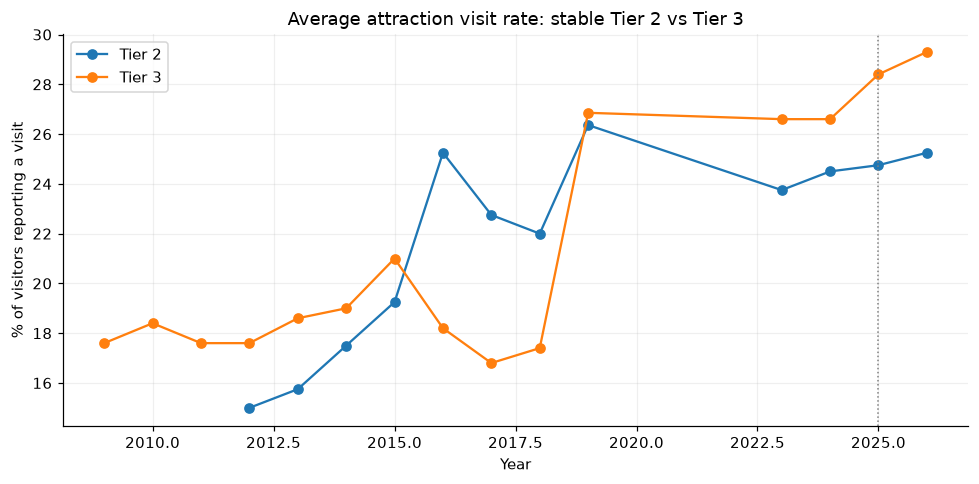

2026 modeled gaps (percentage points):
  POI trend:                  +4.05
  Arrival weighted:           +3.88
  Purchasing-power adjusted:  +3.89

Country contributions to the arrival-weighted raw gap:
               market  tier2_rate_2026  tier3_rate_2026  gap_pp  forecast_arrivals  arrival_weight  pp_index  weighted_gap_contribution_pp  pp_gap_contribution_pp
                India           29.750             40.8  11.050        1127507.820           0.075     0.952                         0.833                   0.784
                China           25.875             29.3   3.425        3215159.209           0.215     1.079                         0.736                   0.786
            Australia           25.250             30.7   5.450        1267380.524           0.085     1.073                         0.462                   0.490
                   UK           31.000             41.0  10.000         543149.017           0.036     1.002                         0.363       

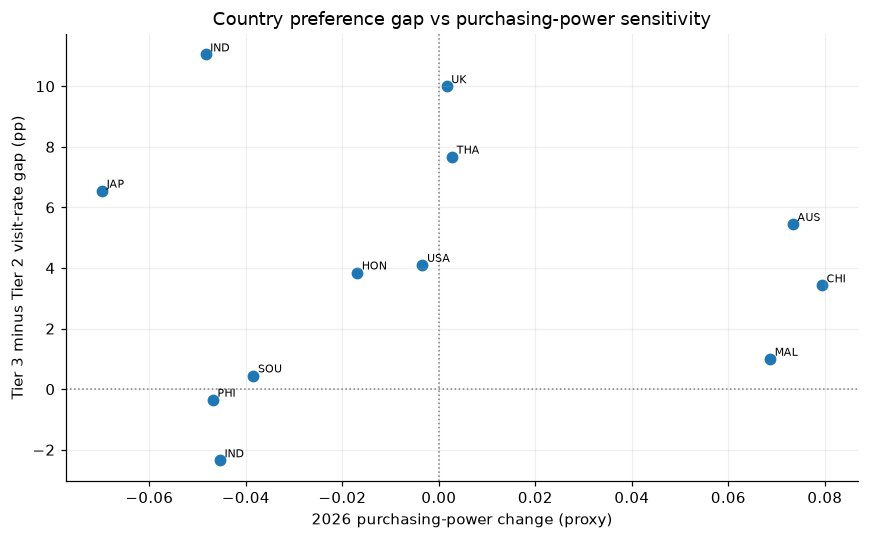


Scenario outputs:
                    angle scenario  realization_factor  uplift_pp  incremental_visitors
                POI trend      Low                0.25       1.01             151405.98
                POI trend     Base                0.50       2.02             302811.97
                POI trend     High                1.00       4.05             605623.94
         Arrival weighted      Low                0.25       0.97             145134.86
         Arrival weighted     Base                0.50       1.94             290269.73
         Arrival weighted     High                1.00       3.88             580539.46
Purchasing-power adjusted      Low                0.25       0.97             145346.33
Purchasing-power adjusted     Base                0.50       1.94             290692.66
Purchasing-power adjusted     High                1.00       3.89             581385.32


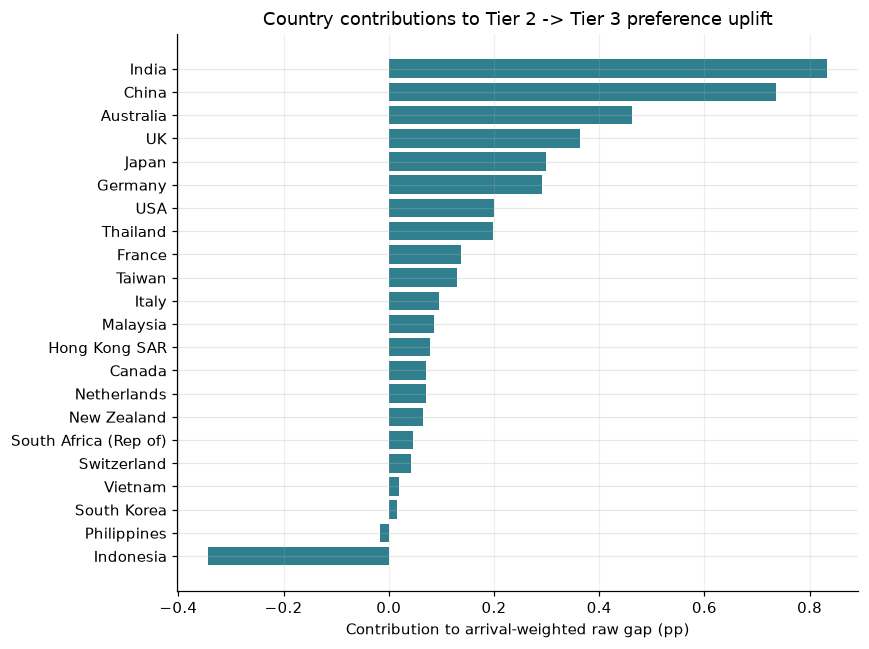


Interpretation: the high case is the full observed association; the base and low cases apply explicit realization factors. This is not a causal estimate of an actual product redesign.


In [ ]:
# Generated Tier 2 -> Tier 3 visitor-uplift analysis
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if not (project_root / "tier_uplift.py").exists():
    project_root = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(project_root))

from tier_uplift import build_tier_panel, forecast_visit_rate_2026

attractions_u = pd.read_csv(project_root / "cleaned_data/profile_attractions.csv")
panel_u = build_tier_panel(attractions_u)

# Angle 1: total-market trend, with 2026 post-reopening trend and flat sensitivity.
total_u = panel_u.loc[panel_u["residence"].eq("TOTAL")]
trend_rows_u = []
for tier_u in (2, 3):
    series_u = total_u.loc[total_u["tier"].eq(tier_u)].set_index("year")["avg_visit_rate"]
    fc_u = forecast_visit_rate_2026(series_u)
    for year_u, value_u in series_u.sort_index().items():
        trend_rows_u.append({"year": int(year_u), "tier": f"Tier {tier_u}", "visit_rate": float(value_u)})
    trend_rows_u.append({"year": 2026, "tier": f"Tier {tier_u}", "visit_rate": fc_u["trend"]})
trend_u = pd.DataFrame(trend_rows_u)
fig_u, ax_u = plt.subplots(figsize=(9, 4.5))
for label_u, sub_u in trend_u.groupby("tier"):
    ax_u.plot(sub_u["year"], sub_u["visit_rate"], marker="o", label=label_u)
ax_u.axvline(2025, color="grey", ls=":", lw=1)
ax_u.set_title("Average attraction visit rate: stable Tier 2 vs Tier 3")
ax_u.set_xlabel("Year"); ax_u.set_ylabel("% of visitors reporting a visit")
ax_u.legend(); ax_u.grid(alpha=0.2); plt.tight_layout(); plt.show()

angle1_u = trend_u.loc[trend_u["year"].eq(2026)].set_index("tier")["visit_rate"]
angle1_gap_u = float(angle1_u["Tier 3"] - angle1_u["Tier 2"])

# Angle 2 and 3: country contribution table and purchasing-power sensitivity.
country_u = pd.read_csv(project_root / "cleaned_data/tier_uplift_country_2026.csv")
scenarios_u = pd.read_csv(project_root / "cleaned_data/tier_uplift_scenarios_2026.csv")
print("2026 modeled gaps (percentage points):")
print(f"  POI trend:                  {angle1_gap_u:+.2f}")
print(f"  Arrival weighted:           {scenarios_u.loc[scenarios_u.angle.eq('Arrival weighted') & scenarios_u.scenario.eq('High'), 'uplift_pp'].iloc[0]:+.2f}")
print(f"  Purchasing-power adjusted:  {scenarios_u.loc[scenarios_u.angle.eq('Purchasing-power adjusted') & scenarios_u.scenario.eq('High'), 'uplift_pp'].iloc[0]:+.2f}")
print("\nCountry contributions to the arrival-weighted raw gap:")
cols_u = ["market", "tier2_rate_2026", "tier3_rate_2026", "gap_pp", "forecast_arrivals", "arrival_weight", "pp_index", "weighted_gap_contribution_pp", "pp_gap_contribution_pp"]
print(country_u[cols_u].sort_values("weighted_gap_contribution_pp", ascending=False).round(3).to_string(index=False))

pp_u = country_u.loc[country_u["gdp_pc_real_growth_pct"].notna()].copy()
fig_u, ax_u = plt.subplots(figsize=(8, 5))
ax_u.scatter(pp_u["pp_index"] - 1, pp_u["gap_pp"], s=45)
for _, row_u in pp_u.iterrows():
    ax_u.annotate(row_u["market"][:3].upper(), (row_u["pp_index"] - 1, row_u["gap_pp"]), fontsize=7, xytext=(3, 2), textcoords="offset points")
ax_u.axhline(0, color="grey", ls=":", lw=1)
ax_u.axvline(0, color="grey", ls=":", lw=1)
ax_u.set_xlabel("2026 purchasing-power change (proxy)")
ax_u.set_ylabel("Tier 3 minus Tier 2 visit-rate gap (pp)")
ax_u.set_title("Country preference gap vs purchasing-power sensitivity")
ax_u.grid(alpha=0.2); plt.tight_layout(); plt.show()

print("\nScenario outputs:")
print(scenarios_u.round(2).to_string(index=False))

bar_u = country_u.sort_values("weighted_gap_contribution_pp", ascending=True)
fig_u, ax_u = plt.subplots(figsize=(8, 6))
ax_u.barh(bar_u["market"], bar_u["weighted_gap_contribution_pp"], color="#2f7f8f")
ax_u.set_xlabel("Contribution to arrival-weighted raw gap (pp)")
ax_u.set_title("Country contributions to Tier 2 -> Tier 3 preference uplift")
ax_u.grid(axis="x", alpha=0.2); plt.tight_layout(); plt.show()

print("\nInterpretation: the high case is the full observed association; the base and low cases apply explicit realization factors. This is not a causal estimate of an actual product redesign.")


# Conclusion

## Q1: Perfomance Snapshot
- Volume is structurally flat: 19.12M (2019) → 16.53M (2024, −13.5%) → 16.91M (2025, −11.6%); flat since mid-2024 → structural plateau, not cyclical.
- Value up, in real terms too: receipts index ~118 vs arrivals ~88 (2019=100); receipts/visitor +34% nominal, +14% real (CPI-deflated); LOS 3.35→3.48; real receipts ≈ parity with 2019.
- Strengths: long-haul leisure above 2019 (Australia, Malaysia, NZ, Canada); Australia share +25%; the +14% real yield; wallet tilting to F&B (+6.0pp) as shopping falls (−4.5pp); solo-ising big markets (China solo 19.5→35%).
- Concerns: China (−15%) and Indonesia (−22%) below own 2019 bases; Vietnam −42%, HK −31%, Japan −29%; hotel occupancy 86.9→81.9% — revenue growth entirely rate-driven (+SGD 52 ARR, unsustainable); top-5 concentration; SGD strong vs all 12 source currencies.

## Q2: Data Meshing
- External data: FX (ECB/Frankfurter), CPI deflator, WDI GDP/cap, receipts-by-residence, Open-Meteo temperature + holiday calendars.
- FX (cell 51): SGD gained buying power vs all 12 markets 2019→2025 (JPY −30%, India −23%, Korea −22%, Indonesia −18%) — Singapore pricier for everyone.
- Purchasing-power residual (cell 52): receipts growth minus GDP/cap-in-SGD = intrinsic attraction; 7/9 markets positive per-arrival (USA +49pp, Japan +46pp, Australia +30pp; only India −16pp negative).
- Uniqueness pays (cell 45): unique-visit share × receipts/arrival r=+0.77 (n=9).
- Seasonality correspondence (cells 31–34): each market's arrival calendar tracks its own holiday calendar, with some temperature correspondence (China, South Korea) — seasonality is programme-driven, not weather-driven.
- What visitors are really doing: the F&B share of receipts rose ~+6pp while shopping fell −4.5pp (receipts components), and visits gravitate to uniquely-Singaporean experiences (tier gradient, 19/22 cross-national tilt).

## Q3: Insights generation
- Segment 1 — Chinese free-independent traveller: #1 market, solo-ising fast (+15.5pp), food-positive, below 2019 but re-growing; biggest single contributor to the uplift.
- Segment 2 — Long-haul Western/Antipodean leisure (AU/US/UK/IN): highest holiday-share gains (+10 to +25pp), couple/family, high yield, high unique-share.
- Pilot — Tier 2 → Tier 3 upgrade prediction (cells 53–54): what happens if a generic T2 POI is upgraded to match average T3 appeal?
- 2026 gap: +4.05pp (POI trend), +3.88pp arrival-weighted, +3.89pp PP-adjusted
- Incremental visitors 2026: Low ~151k / Base 303k / High 606k (weighted: 145k / 290k / 581k)
- Country contributions: China +0.74pp weighted, India +0.83pp, Australia +0.46pp, UK +0.36pp; Indonesia negative (−2.35pp gap, 14.6% of arrivals)
- Reconciles to 2025 benchmarks (3.65pp total / 3.63pp weighted / 15.23M arrivals)
- Honest limits: associational, not causal; confounded by free/paid, accessibility, capacity; no observed POI ever changed tier → cannot identify a causal upgrade effect; named the data needed for a causal test (observed POI transformation / DiD).

## Assumptions & Decisions log

Every non-obvious judgment in this notebook, logged for auditability — including the caveats and qualifiers that bound each claim.

| # | Decision | Rationale / caveat |
|---|---|---|
| 1 | **2019 = 100 baseline** for all indices | Last full pre-COVID year; present in every source. 2020-2022 are a distinct regime, so 2019 is the reference only. |
| 2 | **`period` flag** (`pre_covid`/`covid_gap`/`post_covid`) instead of `.dropna()` | Explicitly excludes the disjointed 2020–Q2-2023 transition rather than silently merging regimes. |
| 3 | **`covid_gap` window = 2020 → Q2-2023** | Singapore reopened borders mainly 2022; travel rules eased through Q1-2023; Q3-2023 onward treated as the new regime. |
| 4 | **Venue tiering is a theory prior, not an estimate** | Tier-3 unique / Tier-2 / Tier-1 generic (destination-uniqueness literature). Introduced in Q2 as a meshing lens; tests ask whether data aligns with the prior. Not an externally validated score. |
| 5 | **Equal-weight, MinMax composite** for the Market Uniqueness Score | No prior that one signal dominates; interpretive and defensible. Used as a cross-check; the headline uniqueness measure is the unique-visit share (Tier-3 visits as % of all tiered visits). |
| 6 | **Receipts components compared as Q4 annual cumulative, by regime** | The receipts workbook is quarterly-YTD, so the Q4 value is the annual total (never sum quarters). Pre/post differences in component shares (e.g., F&B up ~+6pp) are descriptive regime comparisons|
| 7 | **Cross-national breadth reported as a count** | The 19/22-markets unique-visit-share tilt (2019→2024) is presented as a directional count with the market table|
| 8 | **Real-terms via Singapore CPI (all-items)** | Distinguishes behaviour from price; a generic household-basket proxy, not a tourist-price index. |
| 9 | **nationality × age cross-tabs absent** | STB does not publish them; age is aggregate-only (a known gap). |
| 10 | **External data fetched live + cached** | Frankfurter/ECB FX, World Bank WDI GDP/cap, SingStat CPI, Open-Meteo temperature and holiday calendars cached so offline re-runs work; source URLs + observation periods + retrieval dates recorded for auditable provenance. |
| 11 | **Data-type optimisation to `category`** | Correctness aid: closed key-set surfaces merge mismatches. |
| 12 | **Attraction percentages are multi-response visit rates, not shares** | A visitor can report several attractions, so rates do not sum to 100%; tier averages use the arithmetic mean of POI visit rates, never a sum called a "share of POI visits". |
| 13 | **Stable venue set for tier comparisons** | Only venues present in both reference years (2019 and 2024/2025) are compared; `Singapore River` and `Singapore River / Clarke Quay / Boat Quay` are excluded because the survey label changed. |
| 14 | **2024 is the post-COVID reference for the unique-visit-share section** | 2025 receipts-by-residence are Jan-Sep top-3 only, so the 2024 full-year reference is used for receipts-linked plots; the 2019→2024 unique-visit-share result is 19/22 markets up. |
| 15 | **Receipts-by-residence caveats** | Published figures cover only the disclosed top-10 markets; a blank cell means the market was NOT in that year's published top-10 (not zero); amounts exclude Sightseeing / Entertainment / Gaming. |
| 16 | **Receipts per arrival = receipts S$m ÷ arrivals (millions)** | S$ per visitor on the ex-SEG receipt base; arrivals from the IVA item-level series; market-name mapping (Mainland China→China, UK→United Kingdom) applied before joining. |
| 17 | **Receipts-linked correlations are small-n** | Only the top-10 receipt markets enter (n = 9-10), so precision is limited (e.g., unique-share × receipts/arrival r = +0.77, n = 9; repeat × receipts/arrival r = −0.54, n = 10); direction is informative, levels are indicative only. |
| 18 | **All segment correlations are ecological, not individual** | Market-level (22 points), so causal or individual-level claims are not made; confounders include income, age, trip purpose and proximity. |
| 19 | **Pilot framed as a Tier-2 → Tier-3 upgrade prediction, not a message test** | The ONE data-backed pilot: forecast the visit-rate uplift if a generic Tier-2 POI were upgraded to match the average stable Tier-3 POI. Uses the notebook's own venue-tier gap as the falsifiable lever. |
| 20 | **The uplift estimate is associational and scenario-based, not causal** | No observed POI has changed tier in the STB data, so a causal treatment effect cannot be identified; the Low/Base/High cases apply explicit 25%/50%/100% realization factors to the raw historical gap. |
| 21 | **2026 visit-rate forecast rule** | Post-reopening slope (2023-2025) capped to the historical one-year change range and bounded to 0%-100%; a flat-2025 forecast is shown beside the trend forecast as a lower-bound alternative. |
| 22 | **2026 arrival forecast rule** | Same-month YTD seasonal scaling where 2026 data exist; otherwise a 2023-2025 linear trend capped at ±20%; covered markets sum to ~14.95M forecast arrivals. |
| 23 | **Purchasing-power index = (1 + real GDP/cap growth) × FX** | A weakening home currency must reduce Singapore purchasing power (direction tested); index winsorized to [0.85, 1.15] and missing values set to 1.0; shown as a sensitivity, not multiplied into the headline forecast. |
| 24 | **Indonesia and the Philippines have negative Tier-3 minus Tier-2 gaps** | The aggregate uplift is positive overall, but these two markets (Indonesia = 14.6% of forecast arrivals) drag the weighted result — the direction should be read market-by-market, not applied uniformly. |
| 25 | **Confounders of the Tier-2 vs Tier-3 gap** | The gap may reflect free-vs-paid admission, accessibility, capacity, tour inclusion, marketing and survey wording, not uniqueness alone; an actual upgrade does not guarantee the POI inherits every Tier-3 characteristic. |
| 26 | **2025 reconciliation benchmarks** | Total-market gap 3.65pp, 22-country arrival-weighted gap 3.63pp, ~15.23M matched arrivals — reproduced and asserted so the uplift section reconciles to reviewed figures. |


## Annex — Bibliography & provenance

**Literature framing the analysis:**

- **Dann, G. M. S. (1977).** *Anomie, ego-enhancement and tourism.* Annals of
  Tourism Research, 4(4), 184–194. — Push-factor motivation.
- **Crompton, J. L. (1979).** *Motivations for pleasure vacation.* Journal of
  Leisure Research, 11(4), 408–424. — Push/pull dichotomy; cultural pull.
- **Nicolau, J. L., & Más, F. J. (2006).** *The influence of distance and prices on
  the choice of tourist destinations.* Tourism Management, 27(5), 982–996. — Price
  sensitivity; the uniqueness-damps-price framework.
- **Wang, N. (1999).** *Rethinking authenticity in tourism experience.* Annals of
  Tourism Research, 26(2), 349–370. — Experiential/authentic consumption.
- **Kim, J.-H. (2016).** *The relationships between place attachment and
  destination loyalty.* Tourism Management Perspectives. — Place attachment.
- **Mafael, A., et al. (2021).** *Destination uniqueness and choice.* Tourism
  Management. — The core uniqueness-pull mechanism (venue tiering).
- **Jarratt, D., et al. (2019).** *Authenticity and the experience economy.* —
  Experiential value of the authentic.
- **He, J., & Timothy, D. J. (2024).** *Heritage tourism and visitor behaviour.* —
  Heritage precincts as pull factors.
- **Lee, S., Kim, J.-H., & Kim, Y. (2024).** *Food tourism and destination
  identity.* — Food-ways as identity anchors.
- **STB (2019–2025).** *Annual Visitor Profile Statistics*, *International Visitor
  Arrivals*, *Annual Tourism Receipts*, *Hotel Statistics*, *Cruise Statistics*,
  *Outbound Departures* (source workbooks in `data/`).
- **External meshed datasets:** ECB/Frankfurter FX (`other data/fx_monthly.csv`);
  World Bank WDI GDP per capita (`other data/wb_gdp_percap.csv`); SingStat CPI
  (all-items, `other data/cpi_monthly.csv`); Open-Meteo temperature and public /
  school holiday calendars. Purchasing-power inputs are cached with source URLs,
  observation periods and retrieval dates in
  `other data/country_purchasing_power_2026.csv`.
- **Pilot design reference:** `docs/superpowers/specs/2026-08-29-tier2-tier3-poi-uplift-design.md`
  — the Tier-2 → Tier-3 POI visitor-uplift design this notebook implements.

---

### Reproducibility & provenance

All primary tables are read from `data/`; cleaned intermediates are written to
`cleaned_data/`; external API data (FX, WDI GDP/cap, CPI, temperature, holidays)
is fetched live and cached in `other data/`. Every major load ends with a
validation assert. Run cells top-to-bottom to reproduce.

*Prepared as an STB data-pilot submission. All numbers are the author's analysis
of STB-published and public-api data; errors are the author's.*
